In [5]:
import os
import pickle
from collections import defaultdict
from typing import Dict, List

import matplotlib.pyplot as plt
from utils.initiate import initiate_dataset, initiate_model

from condensation.select import (
    random_selection, balanced_by_label, balanced_by_score, select_top, select_bottom,
    balanced_by_score1, balanced_by_range, select_median_centered
)
from condensation.sort_entropy import sort_by_log_percentage_entropy, sort_by_predictive_entropy
from condensation.sort_evidence1 import (
    sort_by_total_evidence_dirichlet, sort_by_label_belief, compute_input_gradient_norm
)

# Lookup tables
scoring_methods = {
    "log_percentage_entropy": sort_by_log_percentage_entropy,
    "predictive_entropy":        sort_by_predictive_entropy,
    "EVIDENCE":                  sort_by_total_evidence_dirichlet,
    "BELIEF":                    sort_by_label_belief,
    "GRADIENT":                  compute_input_gradient_norm
}

selection_methods = {
    "random":             random_selection,
    "balanced_by_label":  balanced_by_label,
    "balanced_by_score":  balanced_by_score,
    "balanced_by_score1": balanced_by_score1,
    "balanced_by_range":  balanced_by_range,
    "top":                select_top,
    "bottom":             select_bottom,
    "median":             select_median_centered
}

DATASETS_DIR = "subsets"
ScoreDistribution = Dict[int, List[float]]

def get_scores_distribution(trainset, model, score_func) -> ScoreDistribution:
    """Score a given trainset and group scores by true label."""
    scores_idx = score_func(model, trainset)
    idx_to_label = {i: lbl for i, (_, lbl) in enumerate(trainset)}
    dist: ScoreDistribution = defaultdict(list)
    for score, idx in scores_idx:
        lbl = idx_to_label.get(idx)
        if lbl is not None:
            dist[lbl].append(score)
    return dist

def plot_distribution(distribution: ScoreDistribution, title: str):
    classes = sorted(distribution.keys())
    data = [distribution[c] for c in classes]
    plt.figure(figsize=(10, 6))
    plt.boxplot(data, labels=classes, showfliers=False)
    plt.xlabel("Class")
    plt.ylabel("Score")
    plt.title(title)
    plt.grid(axis="y", linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.show()

def display_uncertainty_distributions(
    model_name: str,
    dataset_name: str,
    keep_fraction: float,
    scoring_name: str,
    selection_names: List[str],
    plot_average: bool = False
):
    """
    For both direct-checkpoint and file-based:
      • Plot per-suffix distributions (suffixes "1","2","3").
      • If plot_average=True, also pool all suffixes into one distribution and plot that.
    """
    # Validate
    if scoring_name not in scoring_methods:
        raise ValueError(f"Unknown scoring_name '{scoring_name}'. Valid: {list(scoring_methods)}")
    score_fn = scoring_methods[scoring_name]

    suffixes = ["1", "2", "3"]

    # 1) DIRECT (checkpoint-based)
    full_train, _ = initiate_dataset(dataset_name, model_name)
    direct_agg: ScoreDistribution = defaultdict(list)

    for suffix in suffixes:
        # load checkpoint
        chkpt = f"models/{model_name}_{dataset_name}_{suffix}"
        model = initiate_model(model_name, dataset_name, chkpt)

        # score full trainset
        d = get_scores_distribution(full_train, model, score_fn)
        plot_distribution(
            d,
            title=f"DIRECT {scoring_name} — Suffix {suffix}"
        )

        # accumulate for average
        for lbl, scores in d.items():
            direct_agg[lbl].extend(scores)

    if plot_average:
        plot_distribution(
            direct_agg,
            title=f"DIRECT {scoring_name} — Averaged over suffixes 1–3"
        )

    # 2) FILE-BASED (load subsets + score)
    file_agg: ScoreDistribution = defaultdict(list)
    for selection_name in selection_names:
        if selection_name not in selection_methods:
            raise ValueError(f"Unknown selection_name '{selection_name}'. Valid: {list(selection_methods)}")
        for suffix in suffixes:
            # load subset indices
            fname = f"{model_name}-{dataset_name}-{scoring_name}-{selection_name}-{keep_fraction}-{suffix}.pkl"
            path = os.path.join(DATASETS_DIR, fname)
            with open(path, "rb") as f:
                indices = pickle.load(f)

            # rebuild subset & score
            full_train, _ = initiate_dataset(dataset_name, model_name)
            subset = [full_train[i] for i in indices]
            d = get_scores_distribution(subset, model, score_fn)

            plot_distribution(
                d,
                title=f"FILE {scoring_name}+{selection_name} — Suffix {suffix}"
            )

            # accumulate for average
            for lbl, scores in d.items():
                file_agg[lbl].extend(scores)

        if plot_average:
            plot_distribution(
                file_agg,
                title=f"FILE {scoring_name}+{selection_name} — Averaged over suffixes 1–3"
            )


Modified conv1: updated in_channels to 1.
Modified fc layer: updated out_features to 10.
Loaded weights from file: models/resnet18_MNIST_1


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


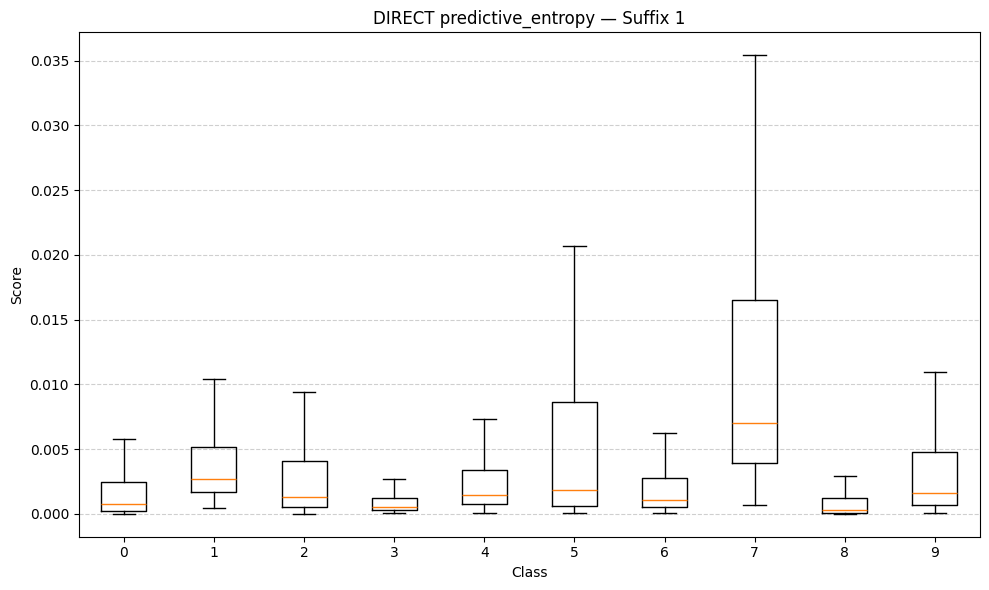

Modified conv1: updated in_channels to 1.
Modified fc layer: updated out_features to 10.
Loaded weights from file: models/resnet18_MNIST_2


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


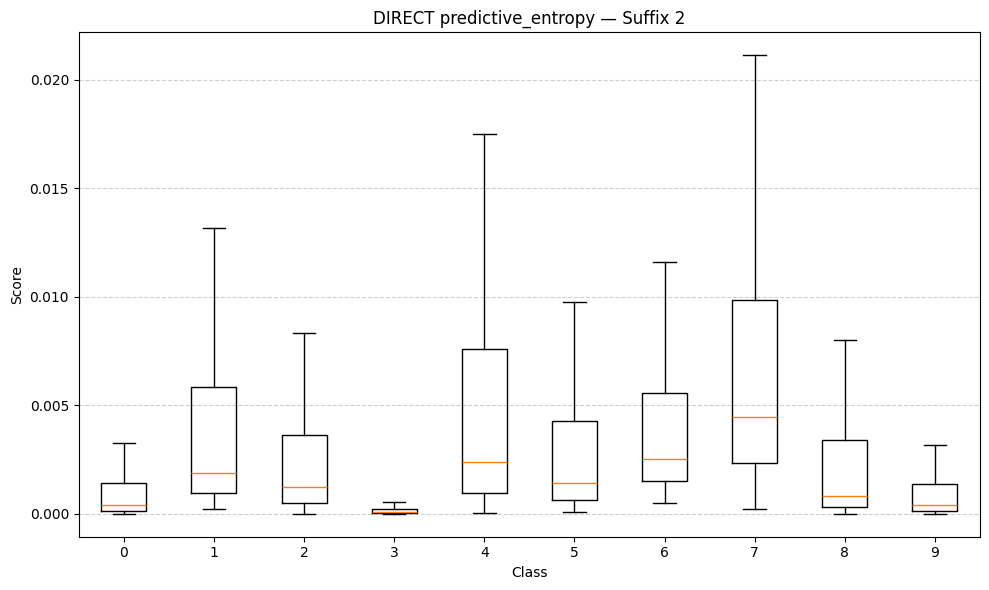

Modified conv1: updated in_channels to 1.
Modified fc layer: updated out_features to 10.
Loaded weights from file: models/resnet18_MNIST_3


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


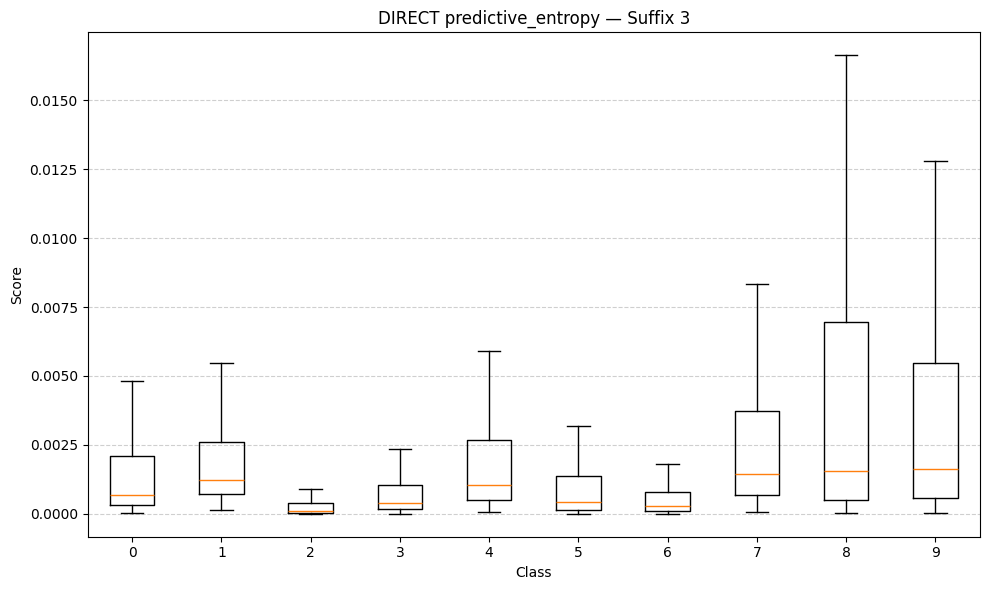

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


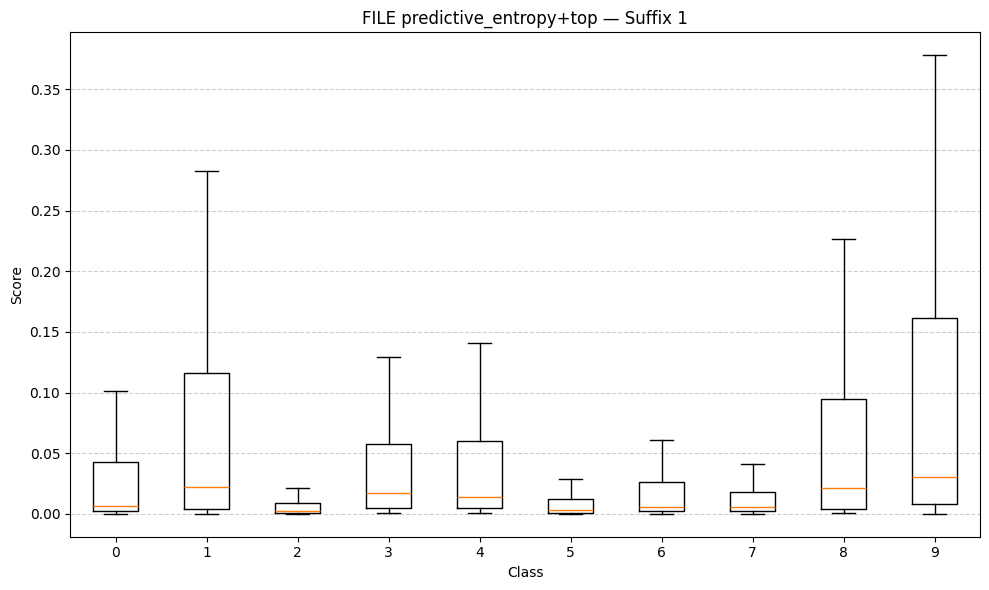

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


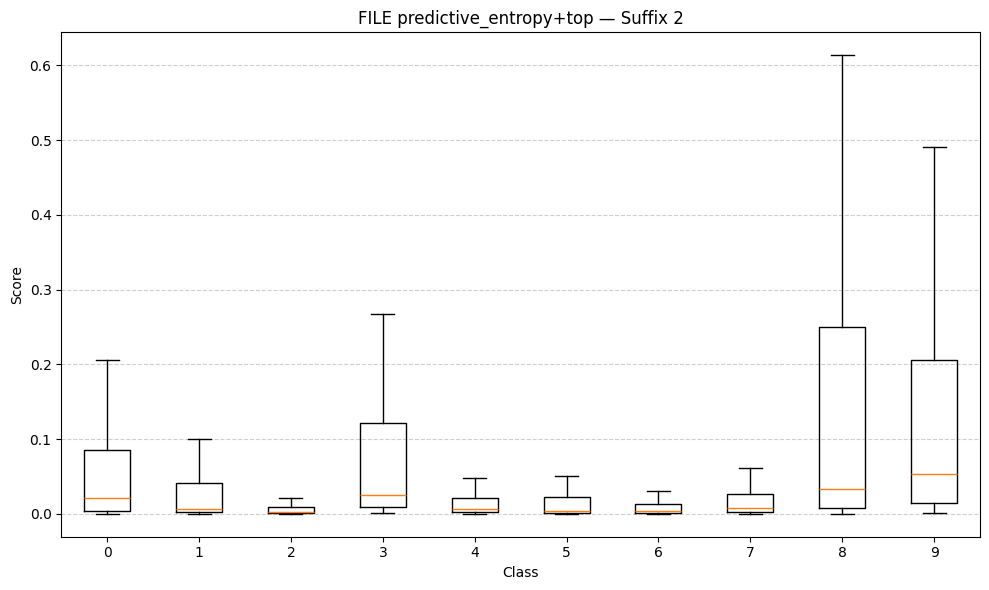

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


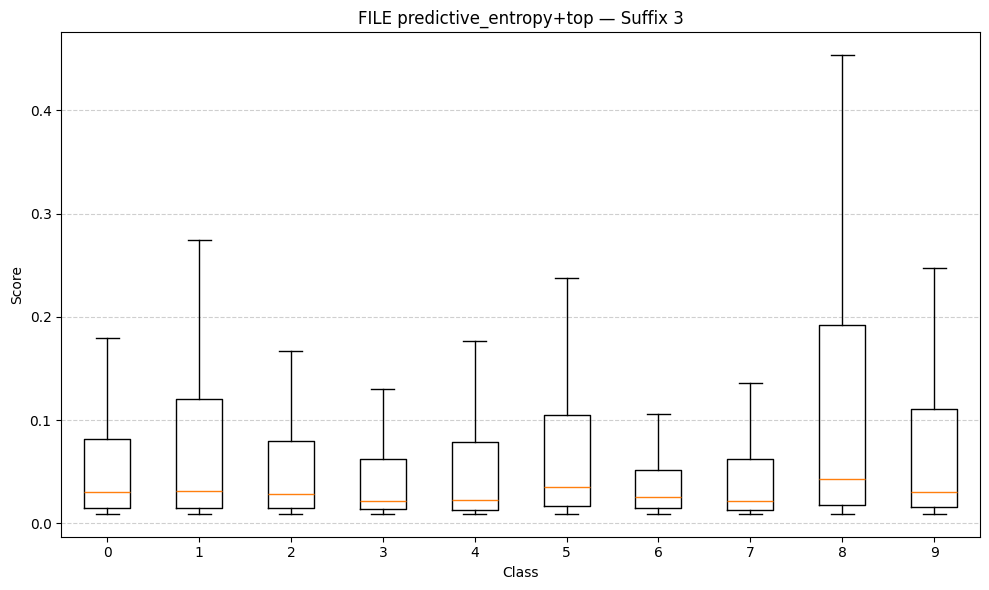

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


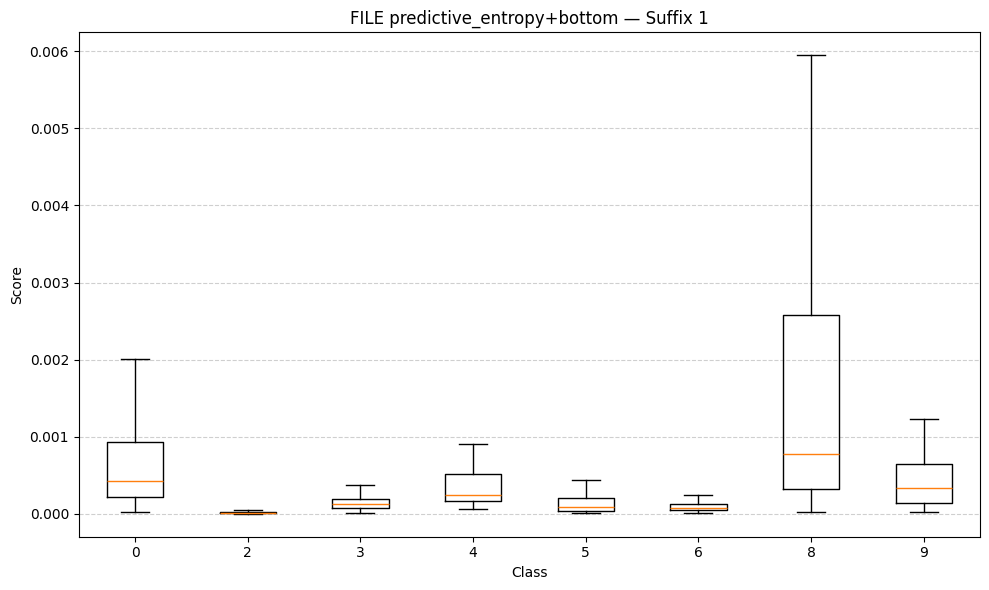

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


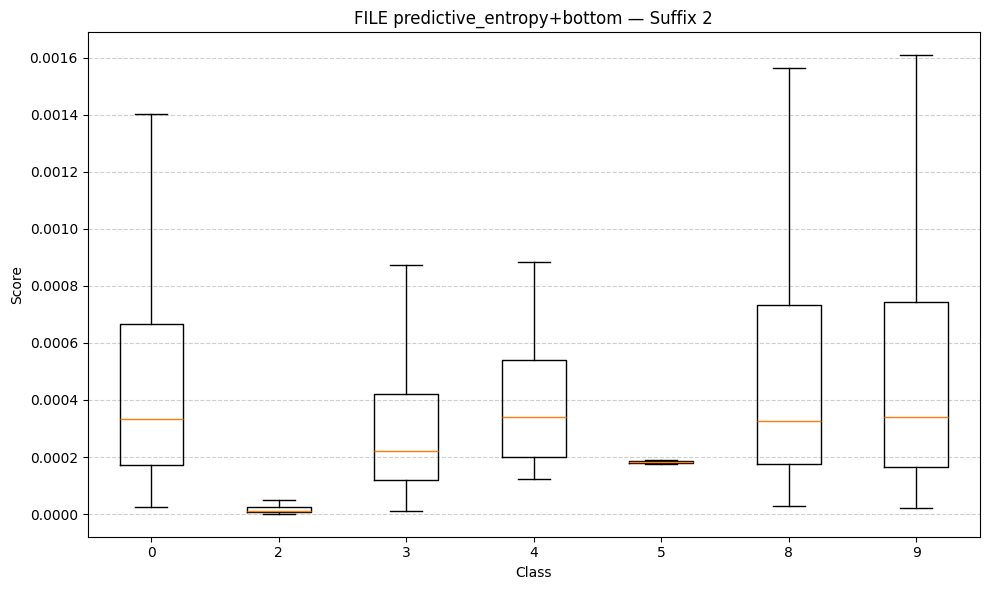

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


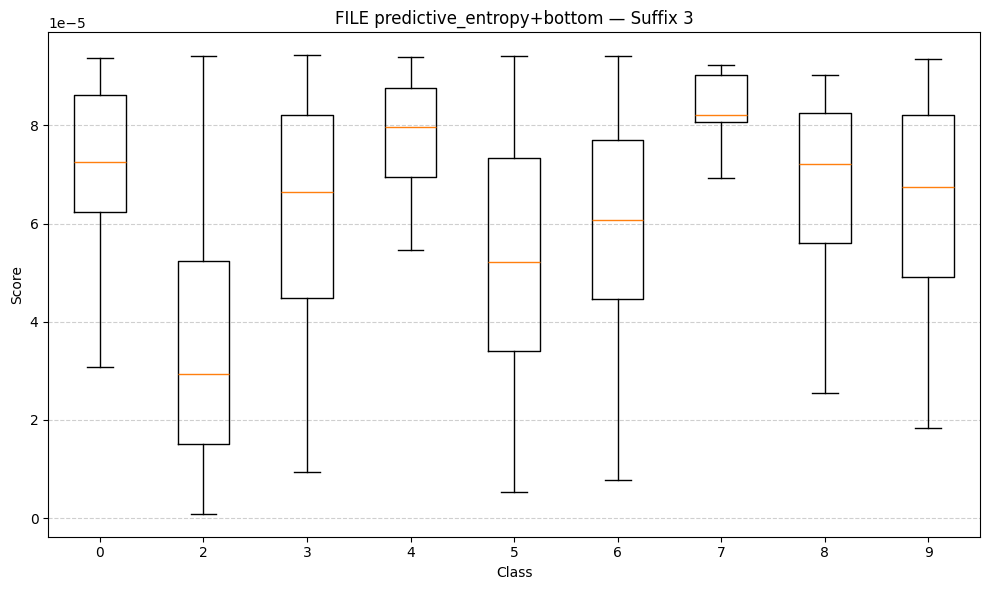

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


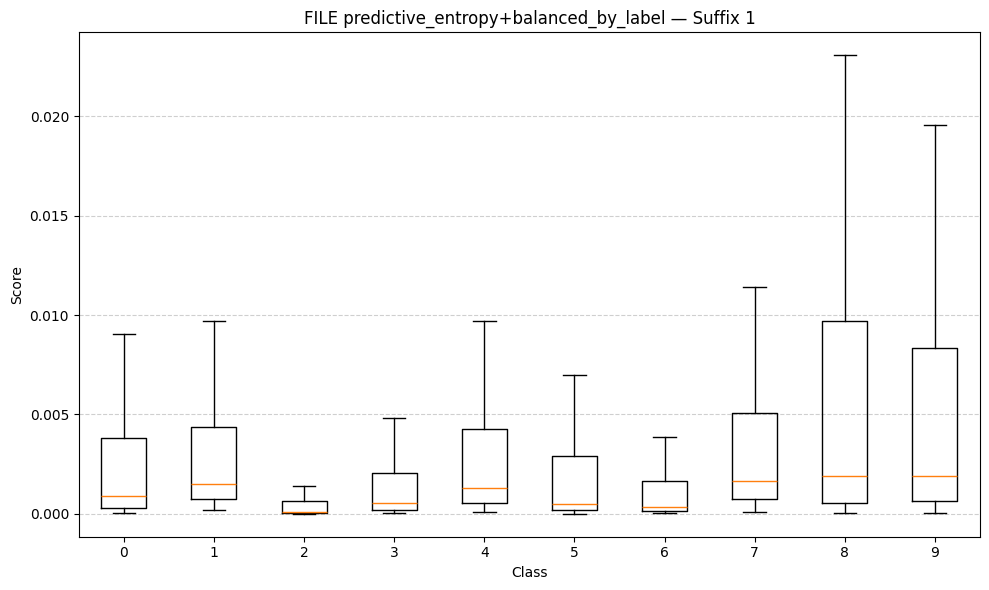

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


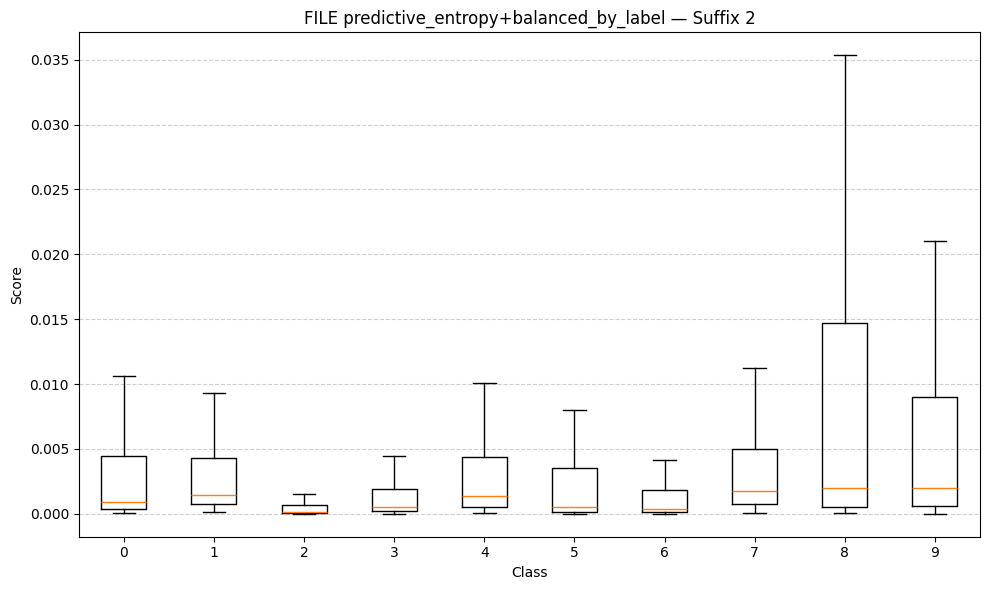

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


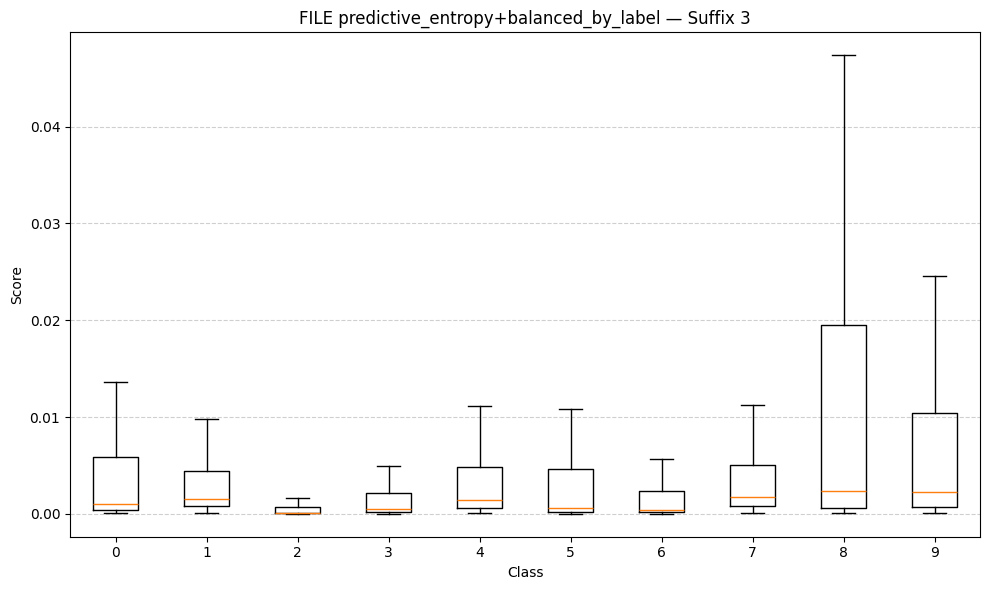

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


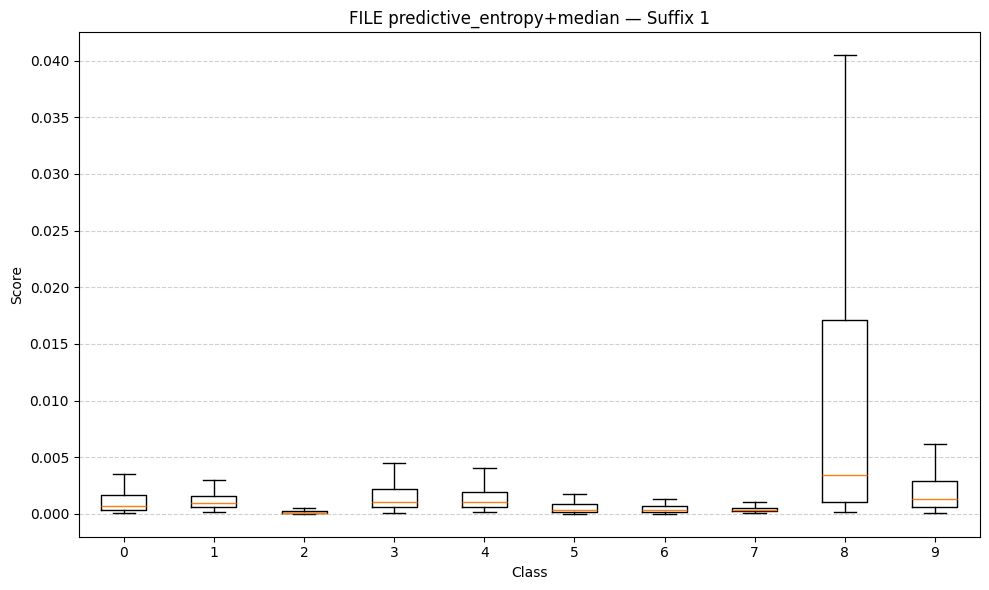

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


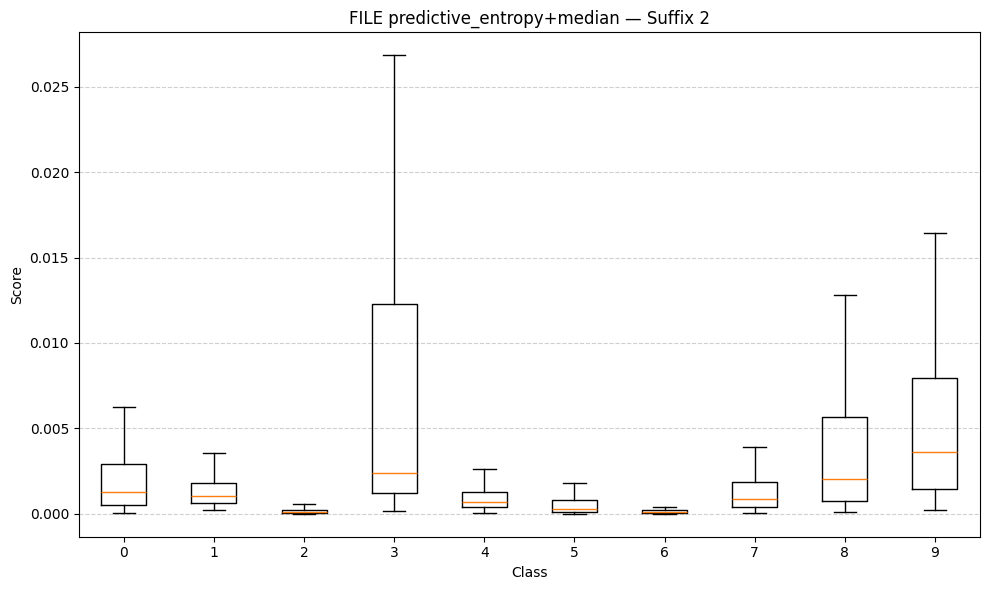

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


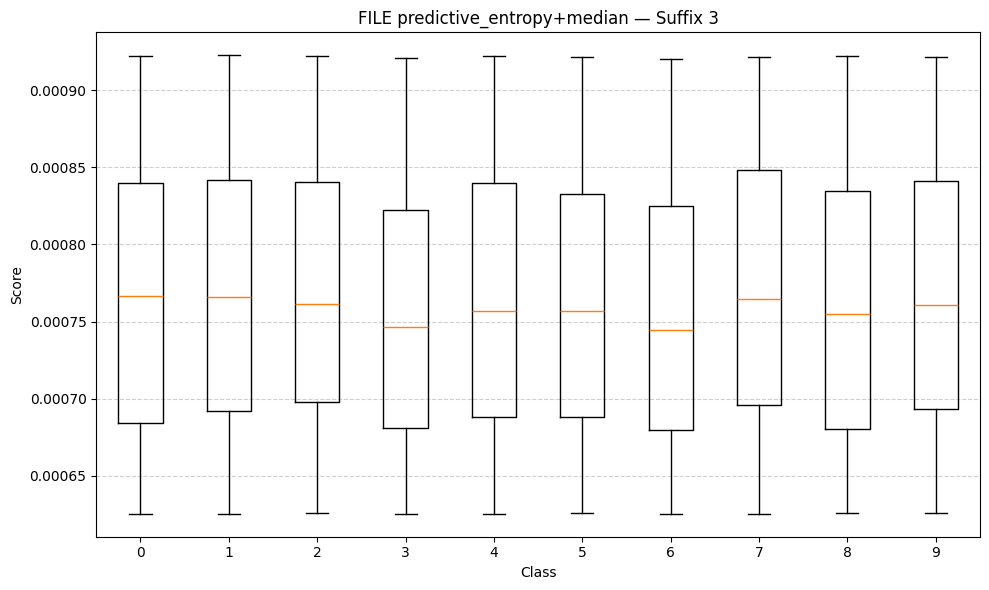

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


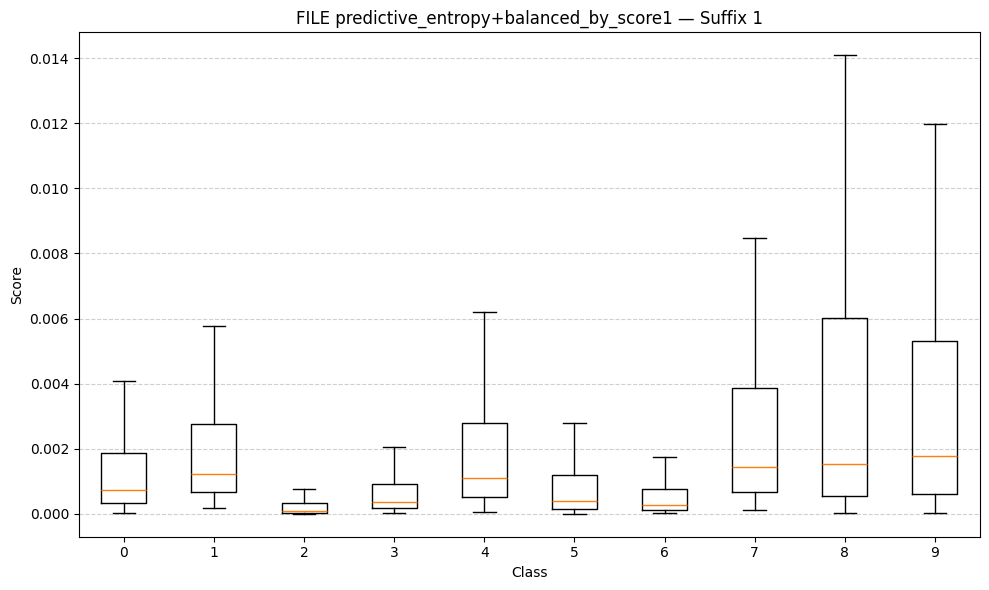

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


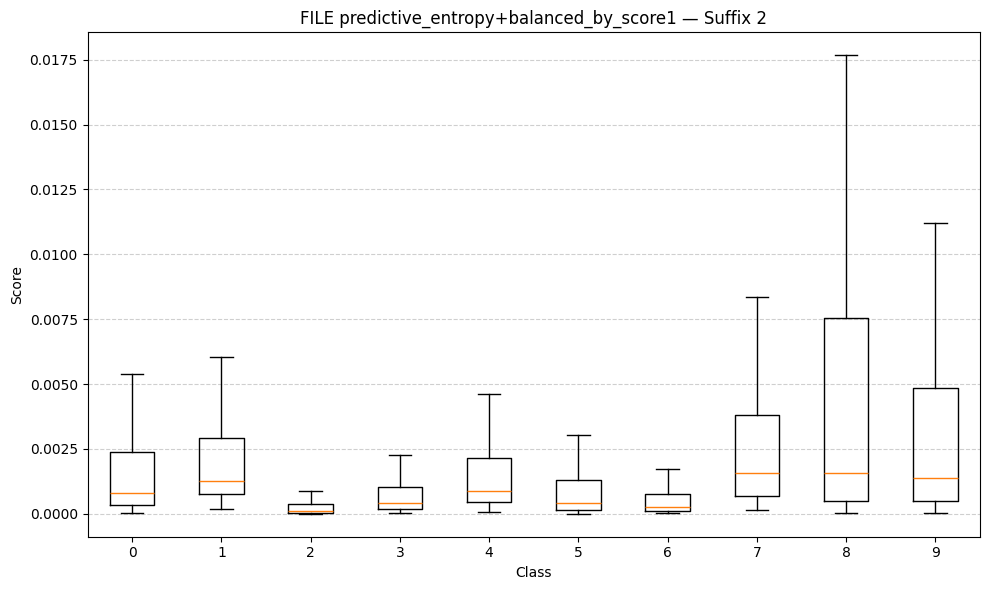

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


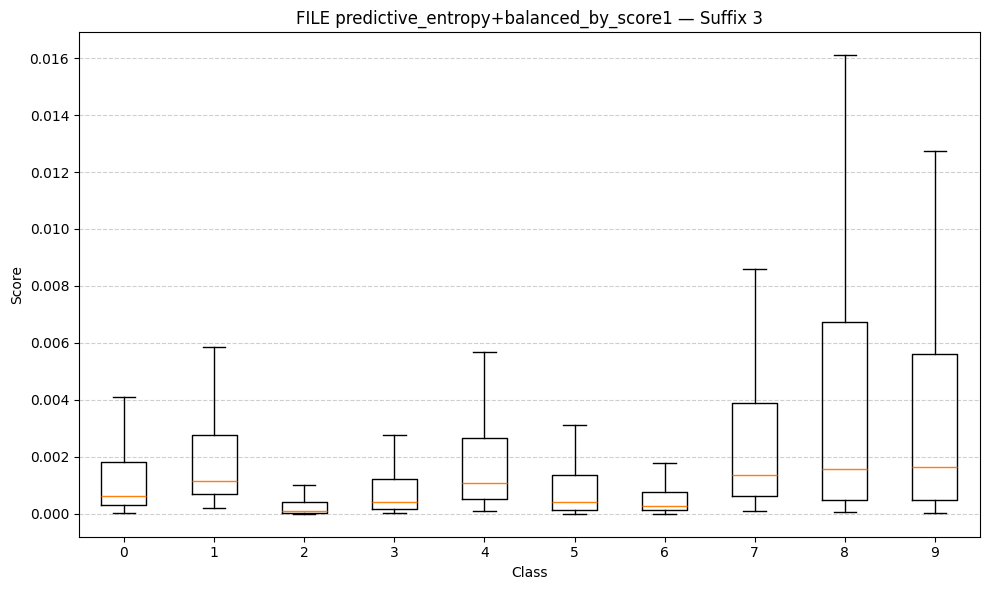

In [6]:
# Per-suffix only:
display_uncertainty_distributions(
    model_name="resnet18",
    dataset_name="MNIST",
    keep_fraction=0.9,
    scoring_name="predictive_entropy",
    selection_names=["top","bottom","balanced_by_label","median","balanced_by_score1"],
    plot_average=False
)

Modified conv1: updated in_channels to 1.
Modified fc layer: updated out_features to 10.
Loaded weights from file: models/resnet18_MNIST_1


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


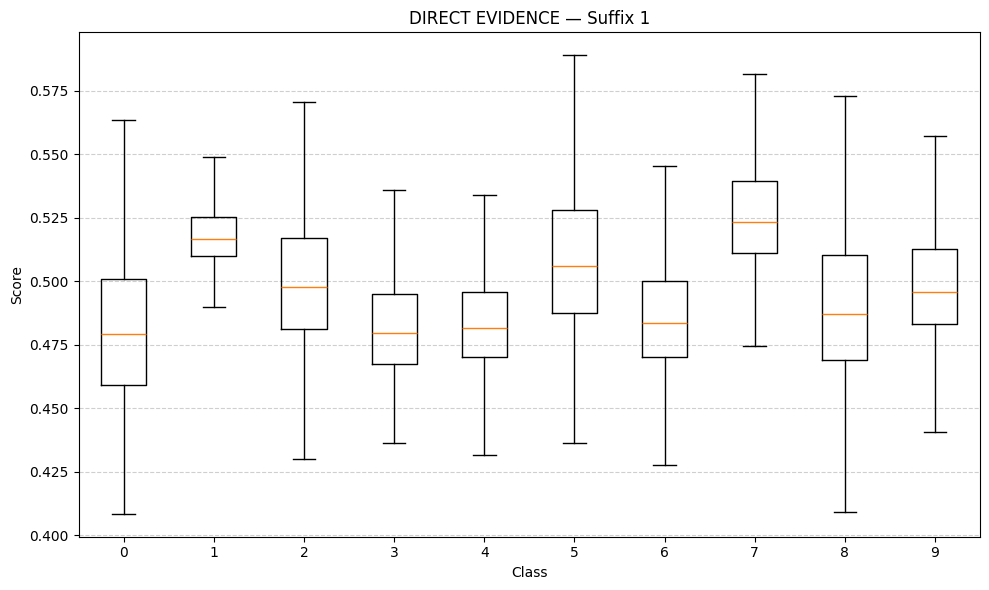

Modified conv1: updated in_channels to 1.
Modified fc layer: updated out_features to 10.
Loaded weights from file: models/resnet18_MNIST_2


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


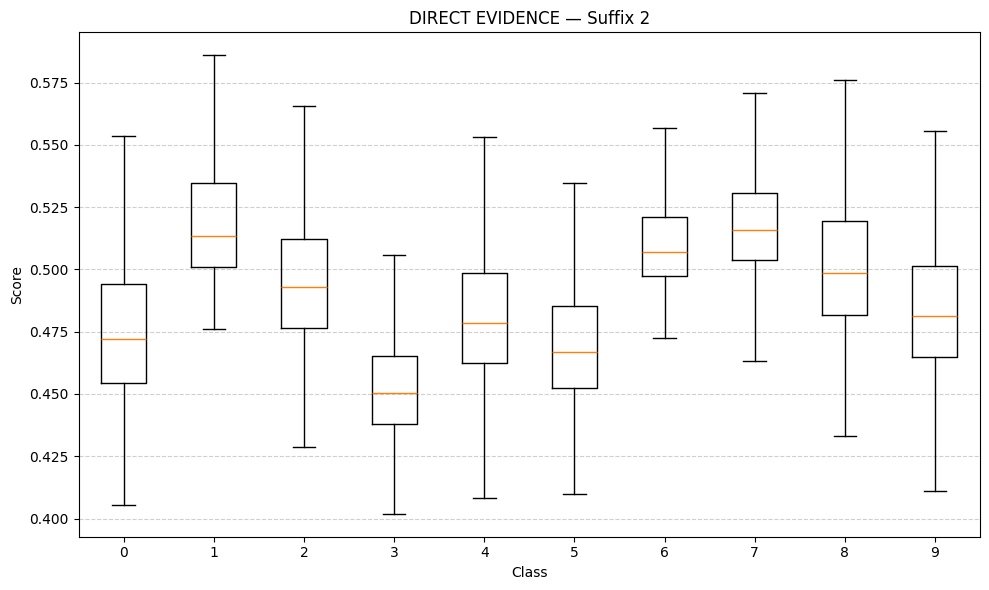

Modified conv1: updated in_channels to 1.
Modified fc layer: updated out_features to 10.
Loaded weights from file: models/resnet18_MNIST_3


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


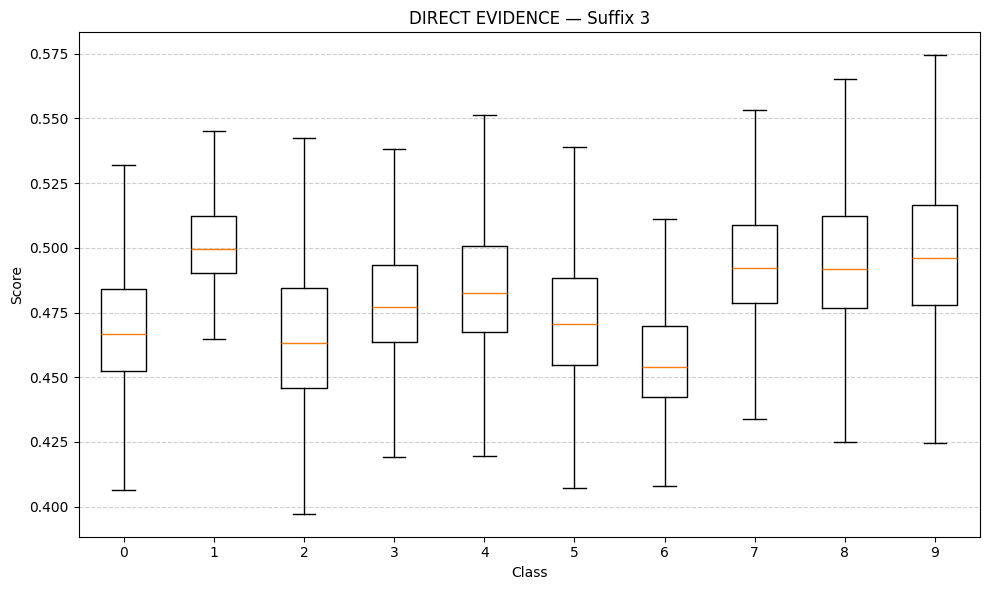

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


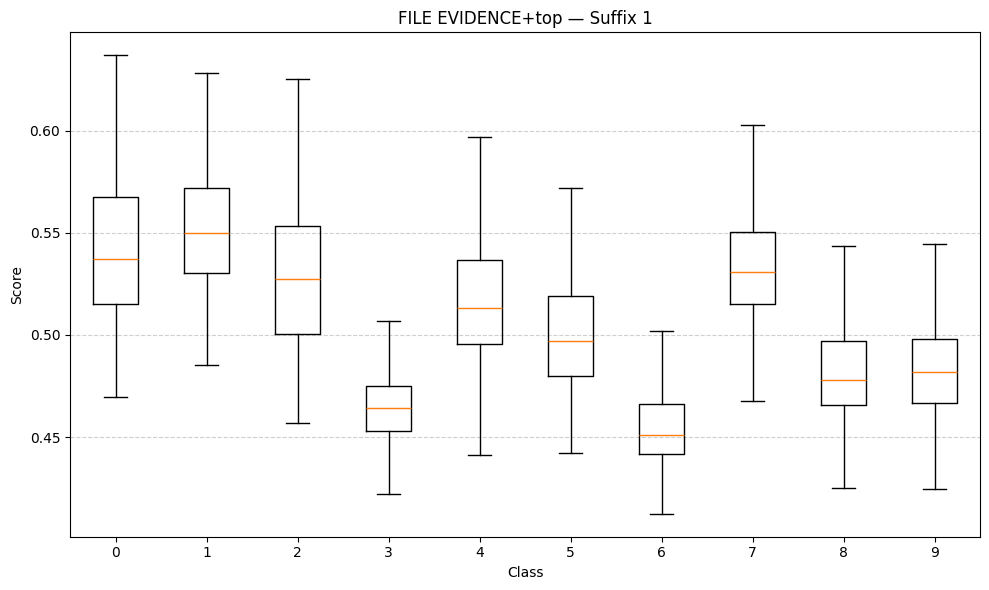

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


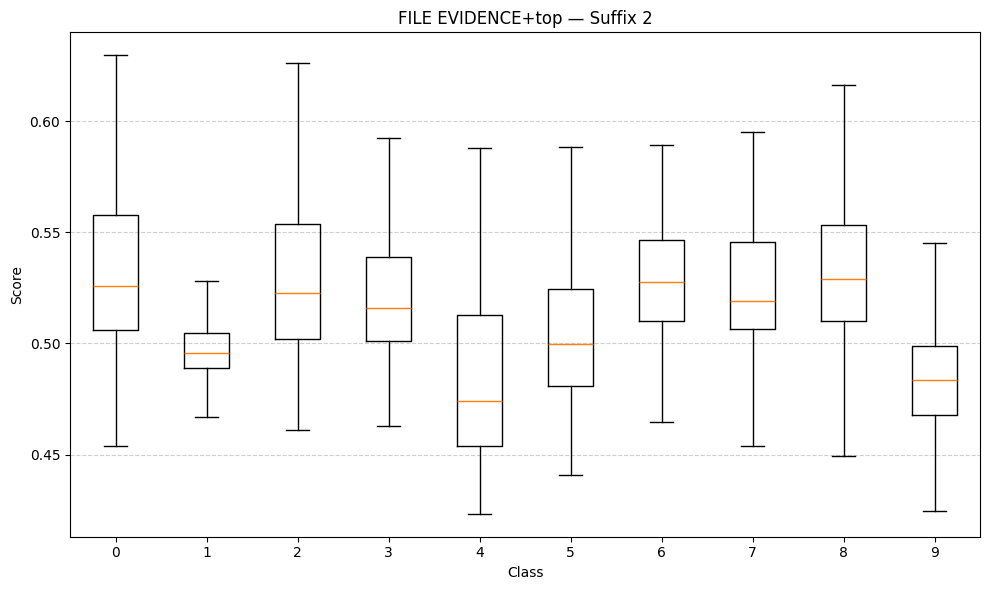

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


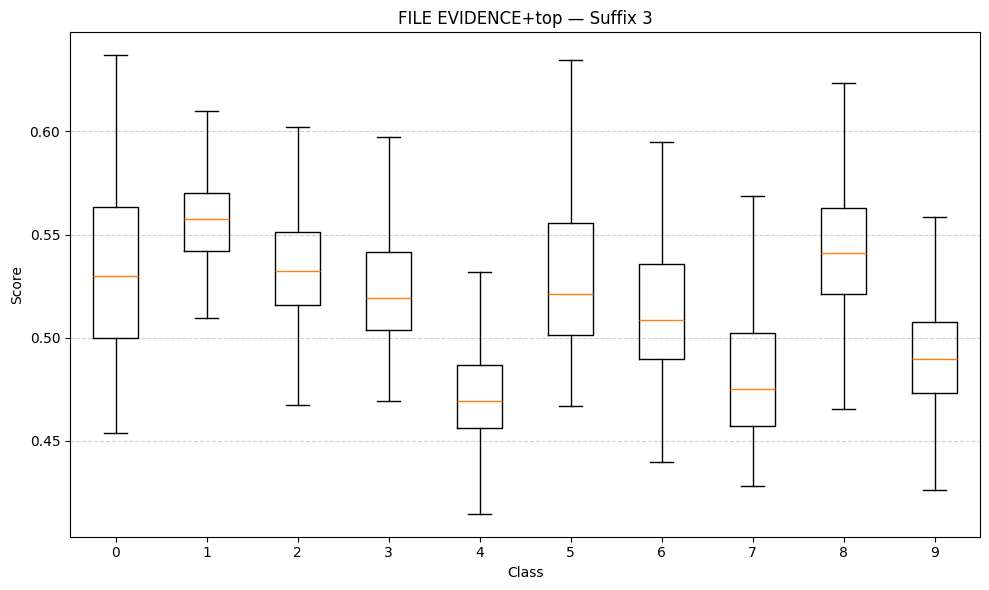

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


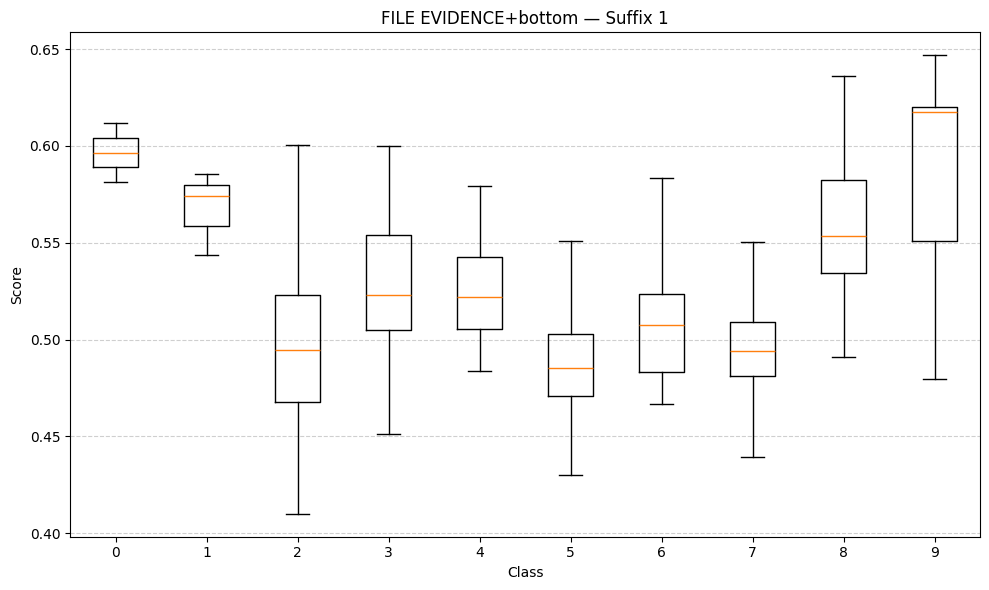

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


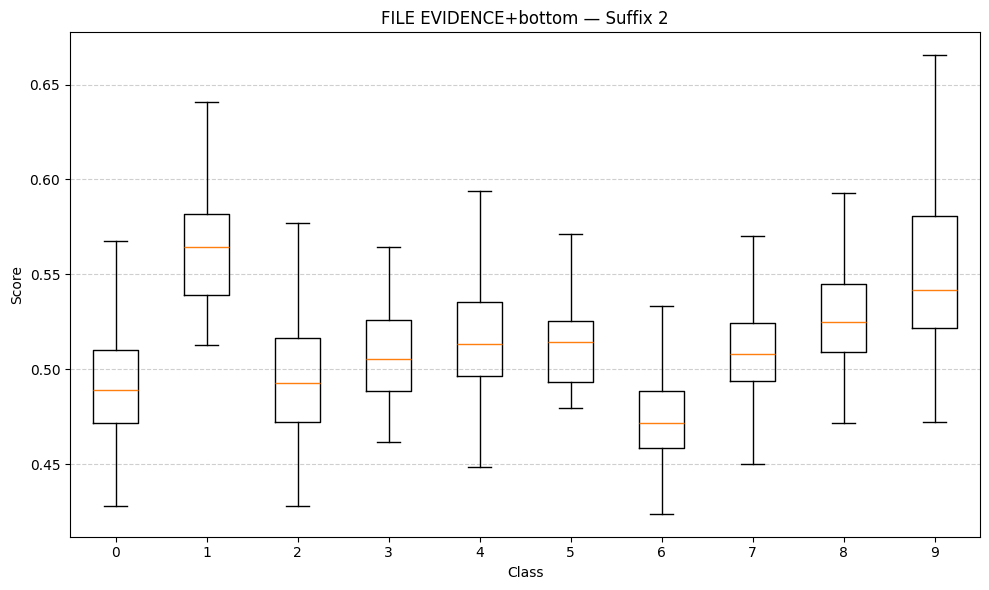

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


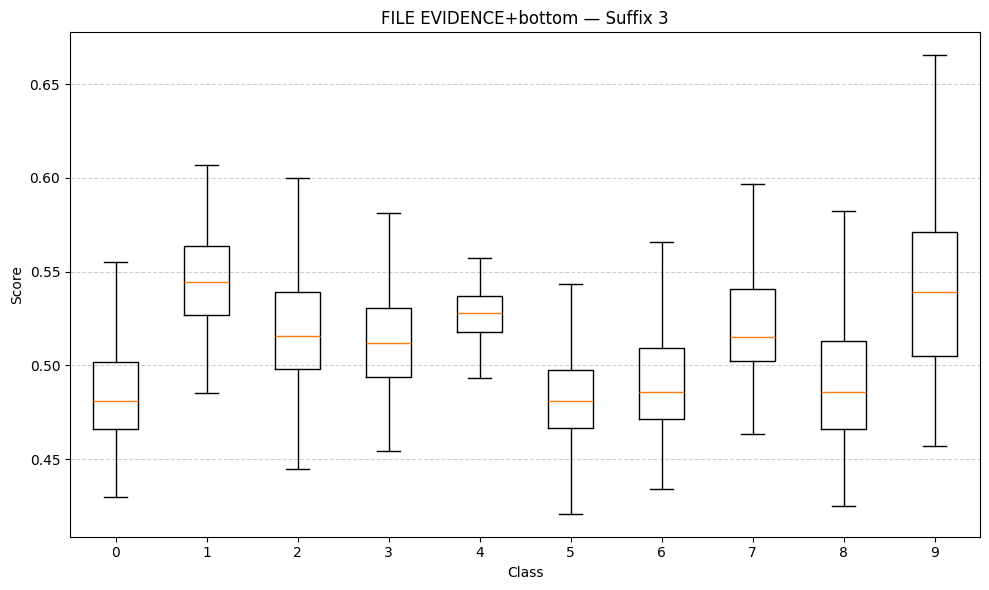

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


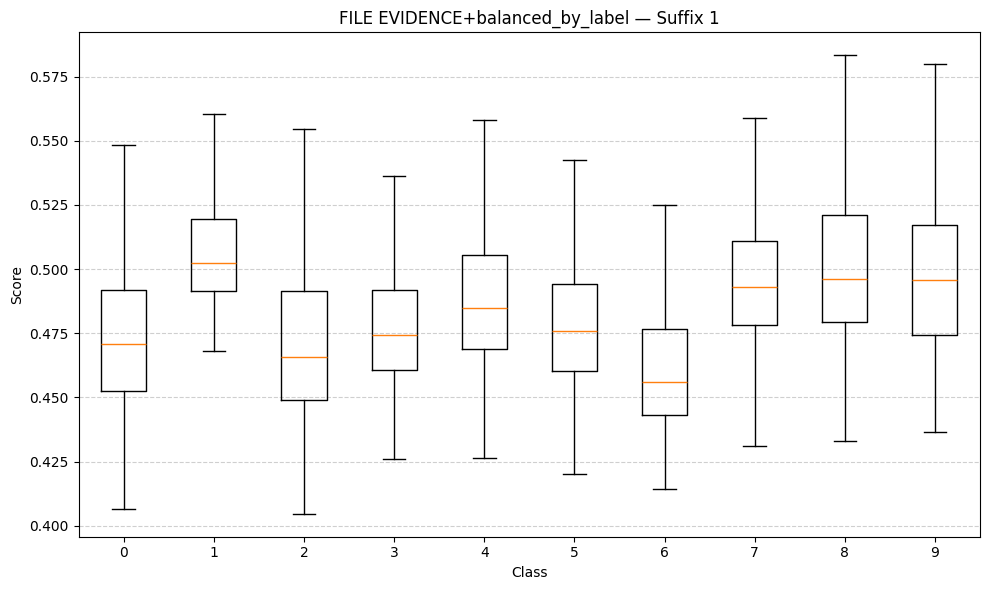

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


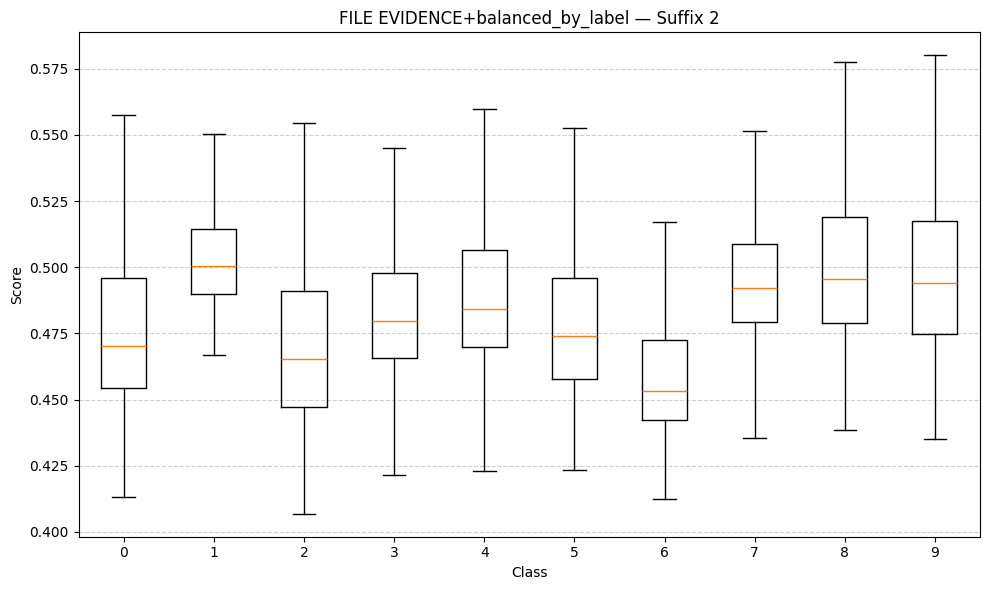

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


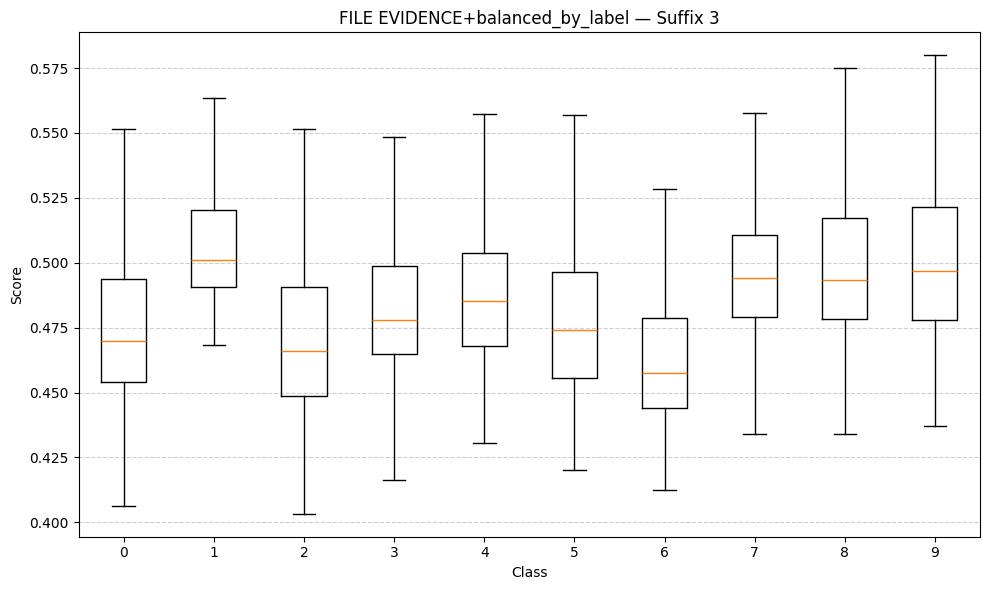

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


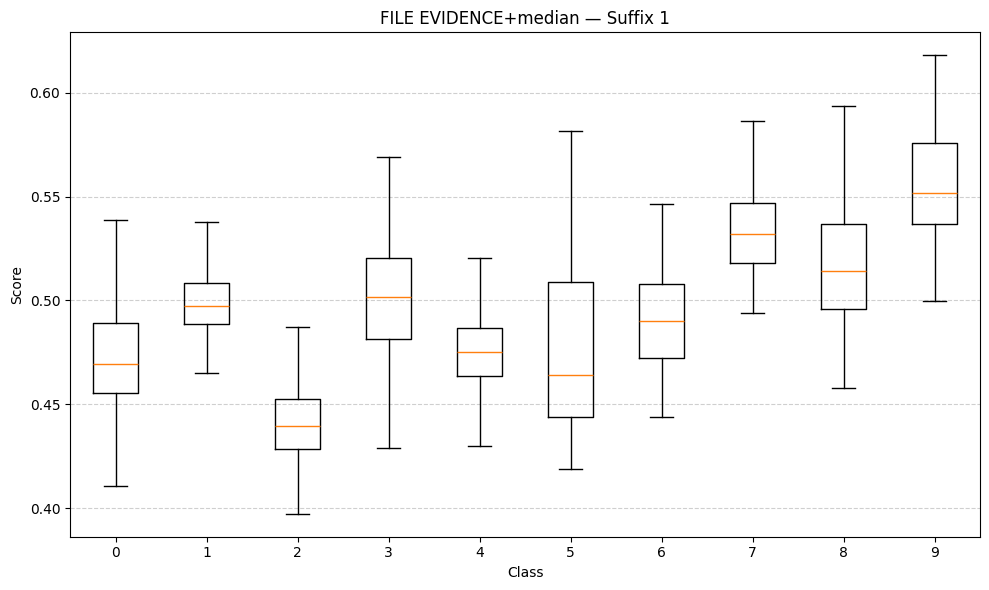

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


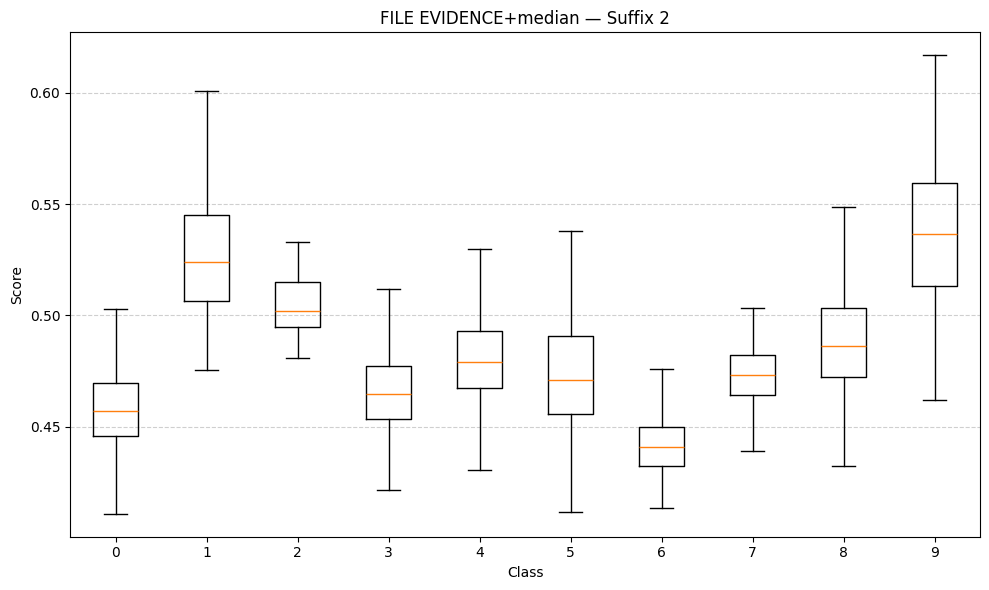

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


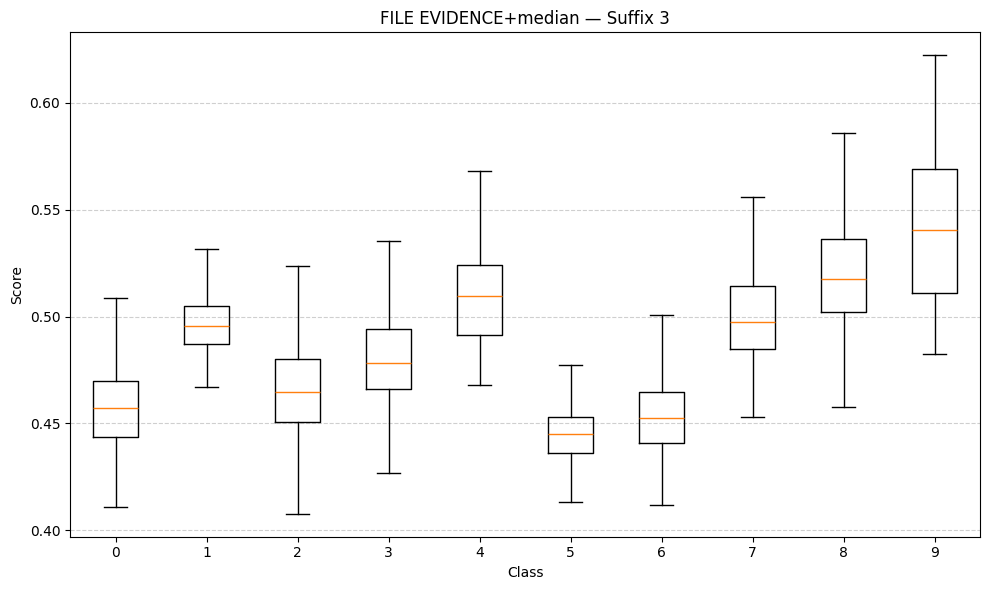

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


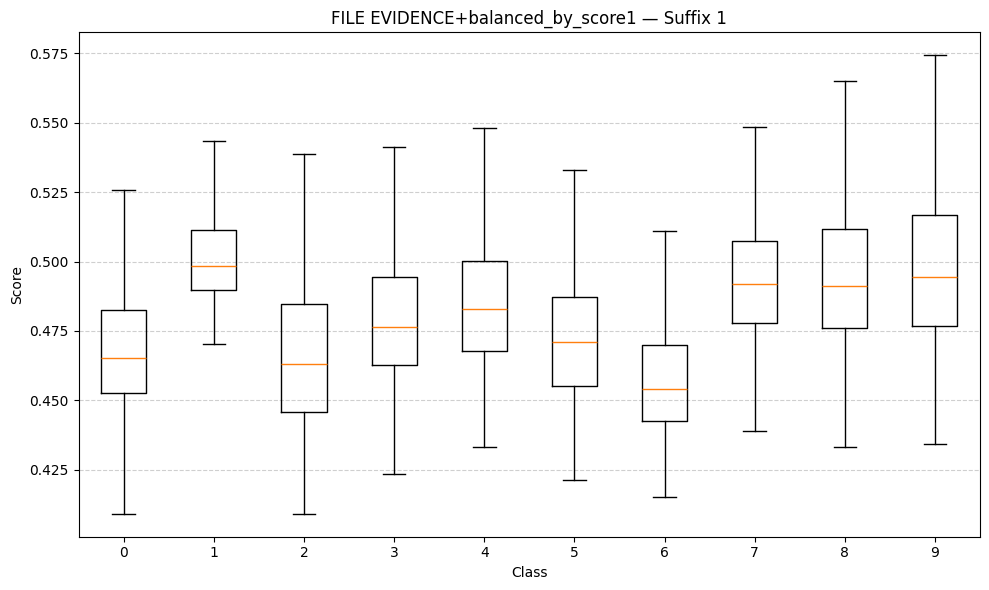

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


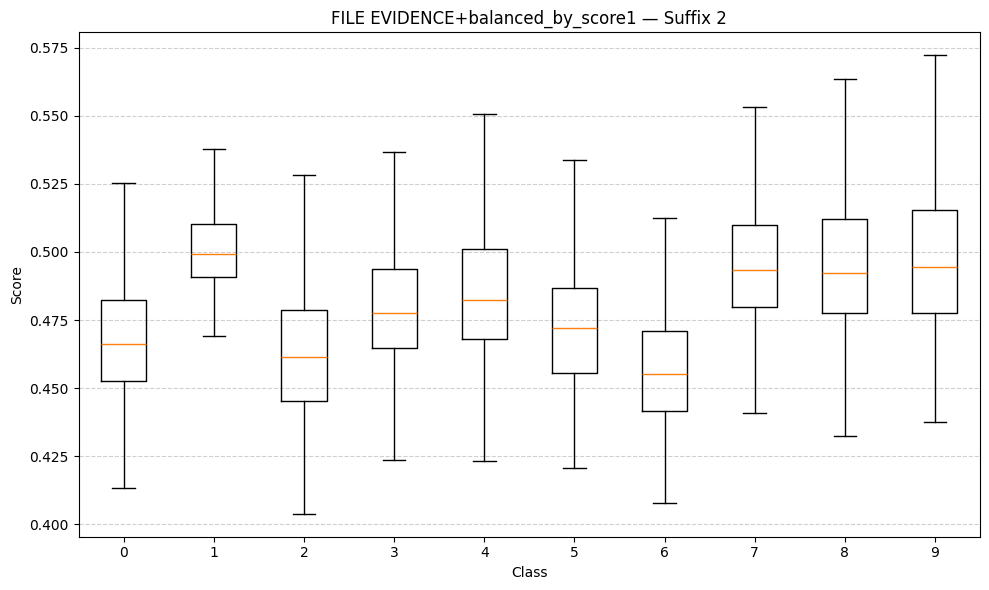

C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


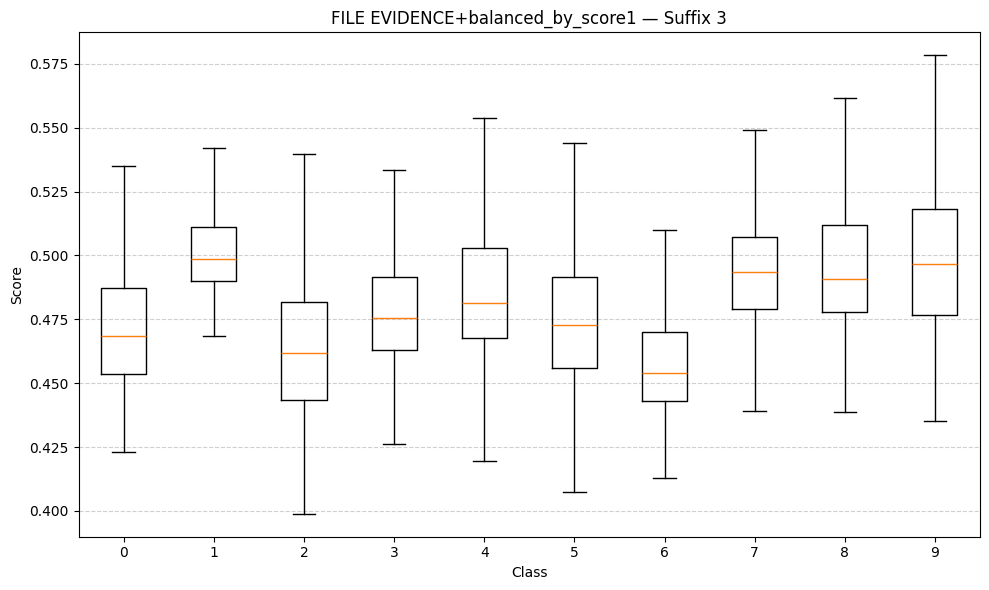

In [7]:
# Per-suffix only:
display_uncertainty_distributions(
    model_name="resnet18",
    dataset_name="MNIST",
    keep_fraction=0.9,
    scoring_name="EVIDENCE",
    selection_names=["top","bottom","balanced_by_label","median","balanced_by_score1"],
    plot_average=False
)

Files already downloaded and verified
Files already downloaded and verified
Modified fc layer: updated out_features to 10.
Loaded weights from file: models/resnet18_CIFAR10_1


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


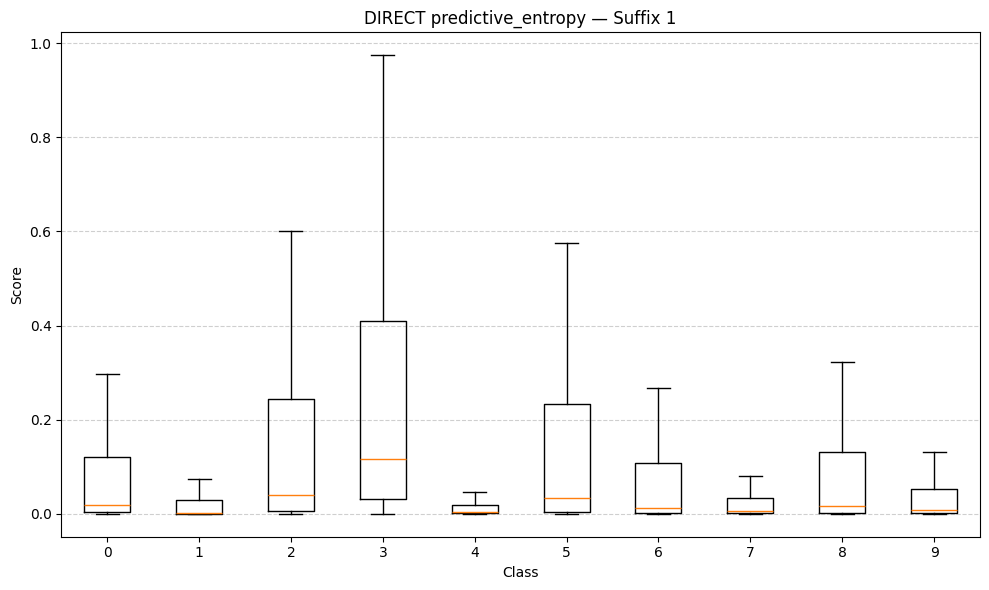

Modified fc layer: updated out_features to 10.
Loaded weights from file: models/resnet18_CIFAR10_2


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


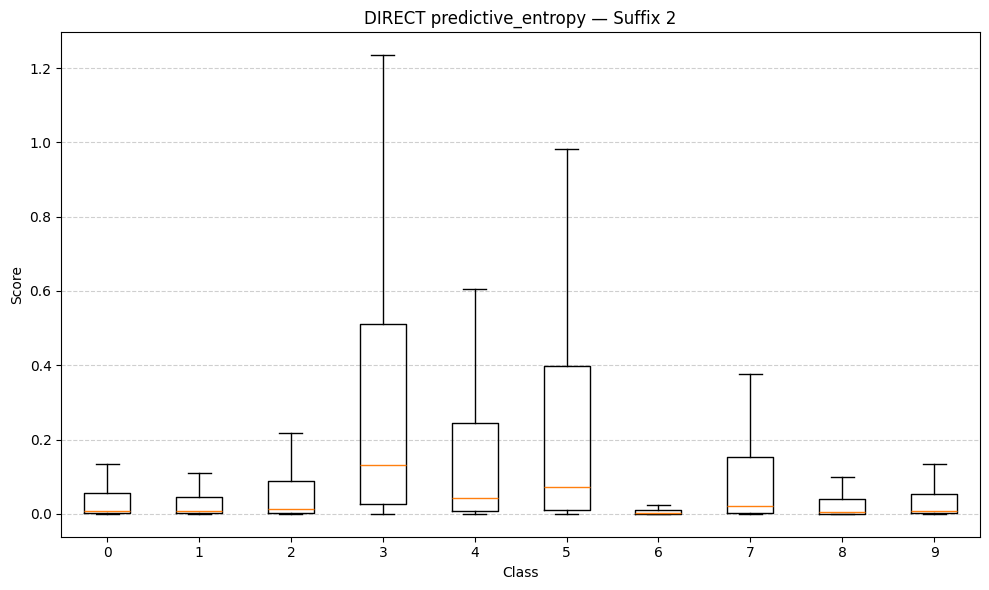

Modified fc layer: updated out_features to 10.
Loaded weights from file: models/resnet18_CIFAR10_3


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


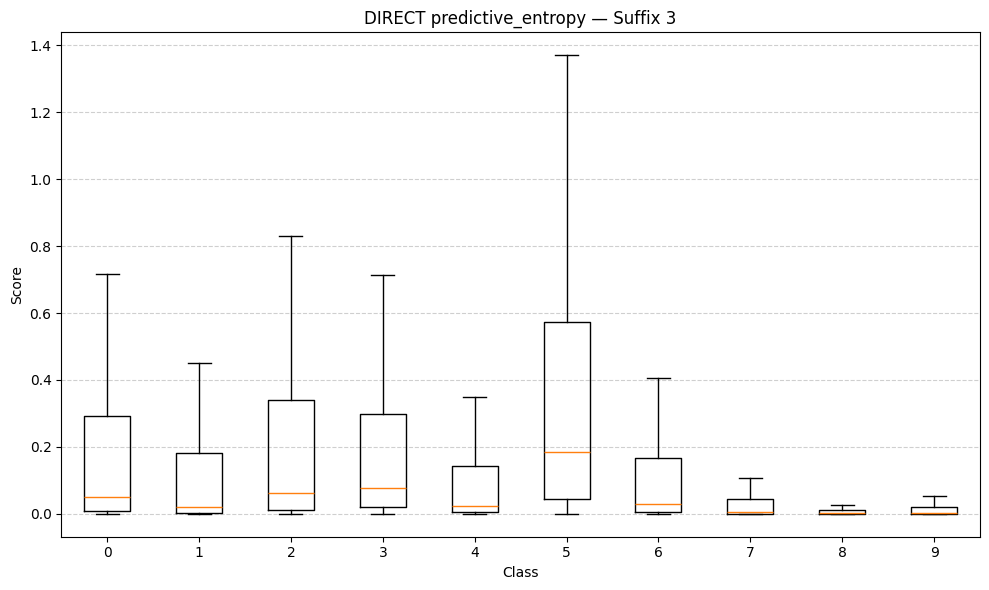

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


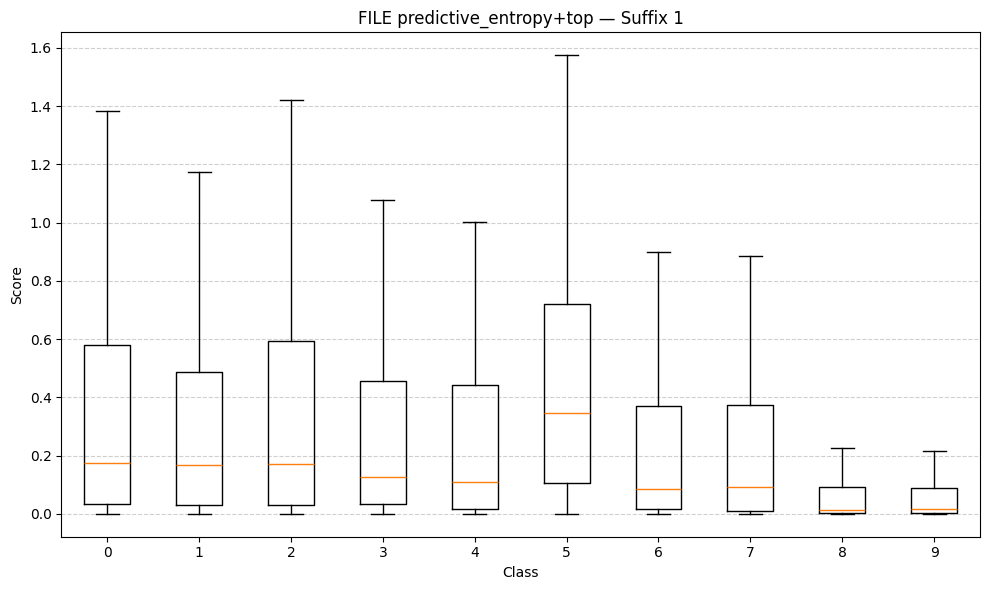

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


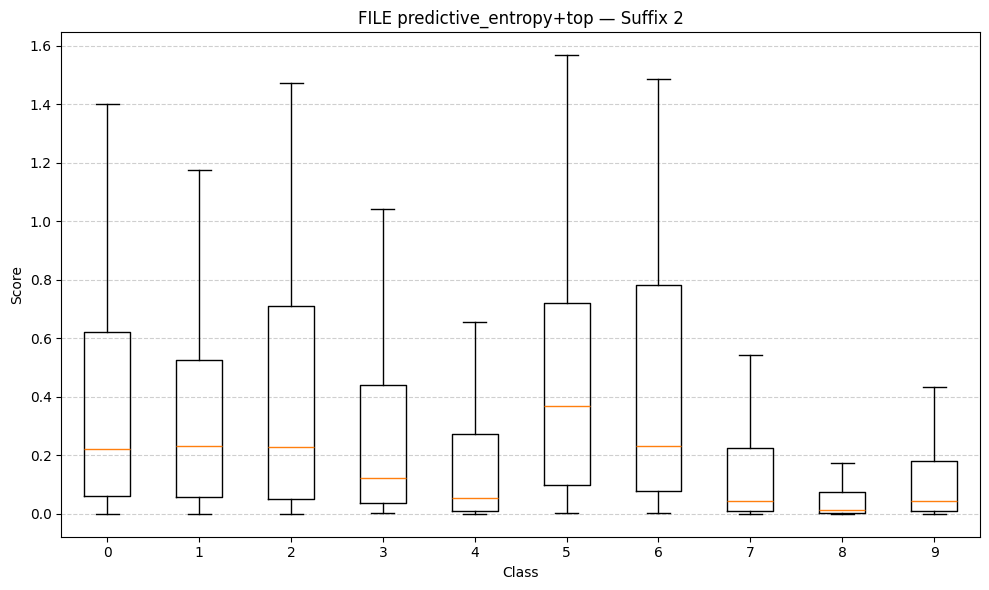

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


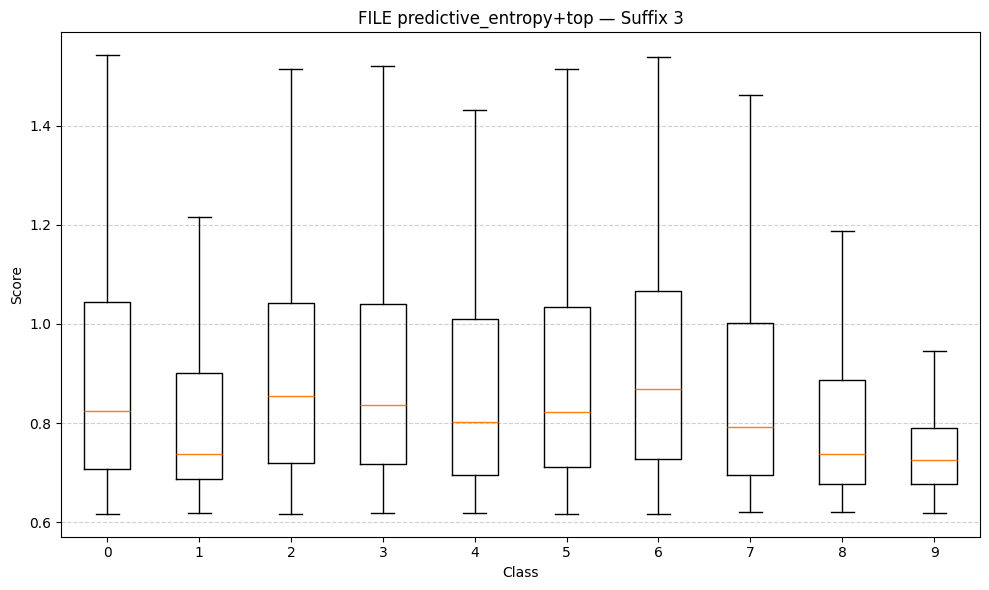

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


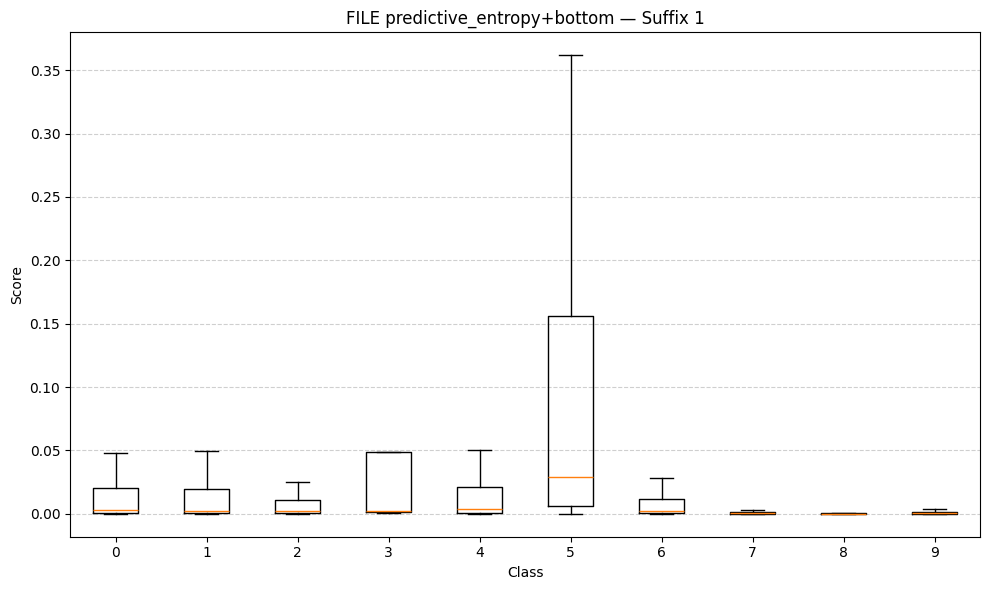

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


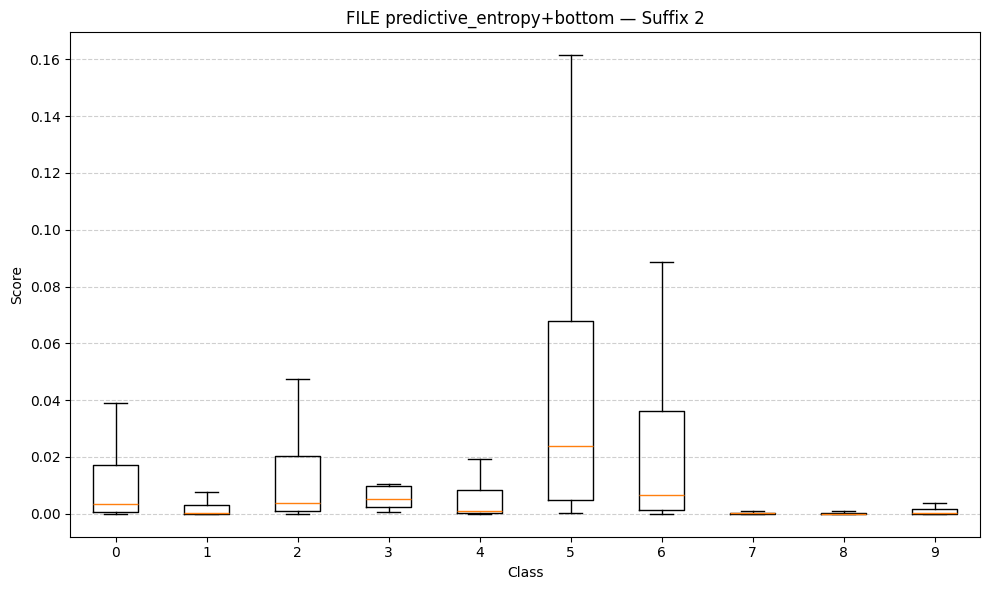

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


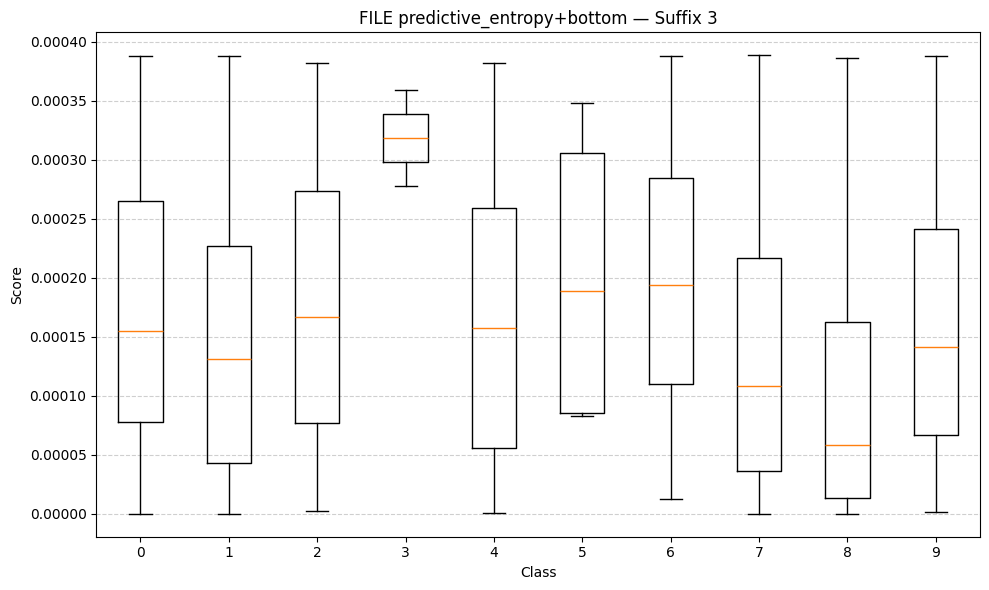

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


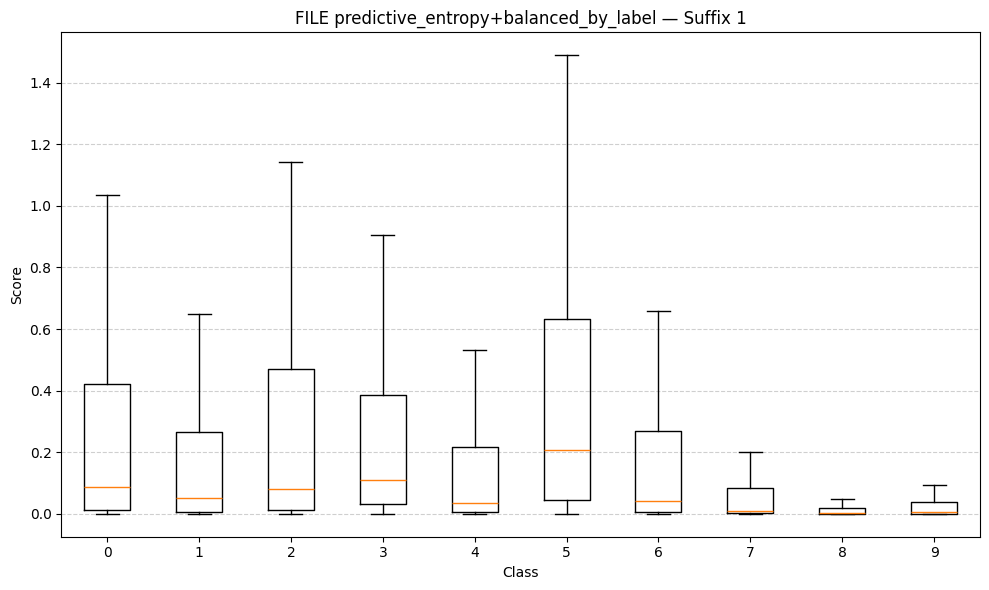

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


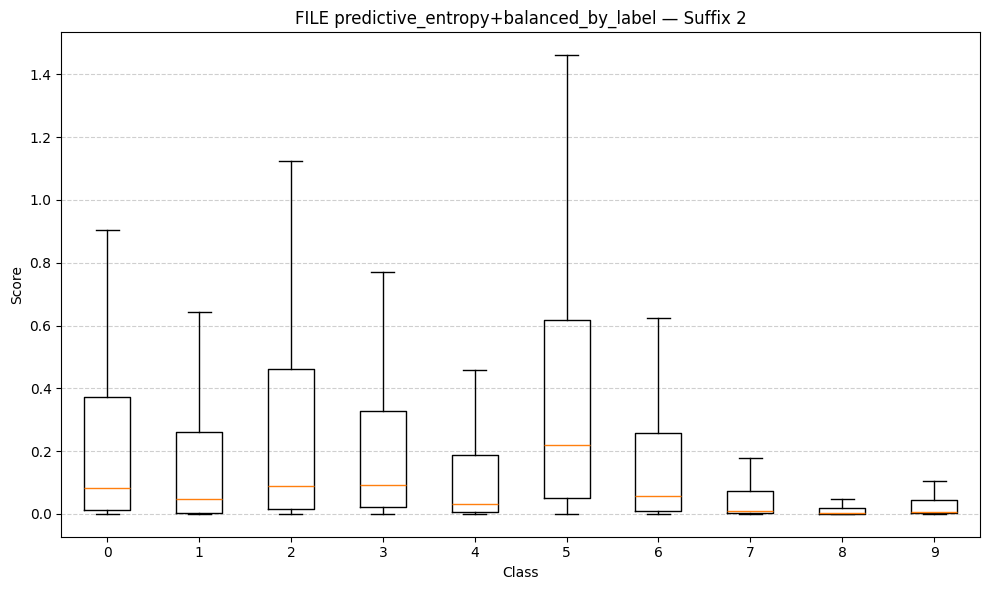

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


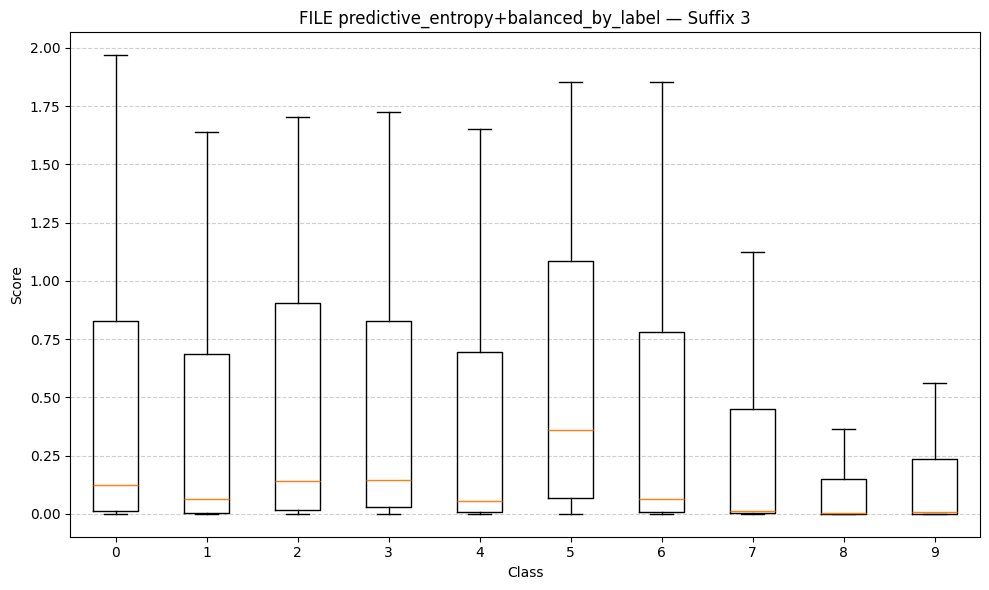

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


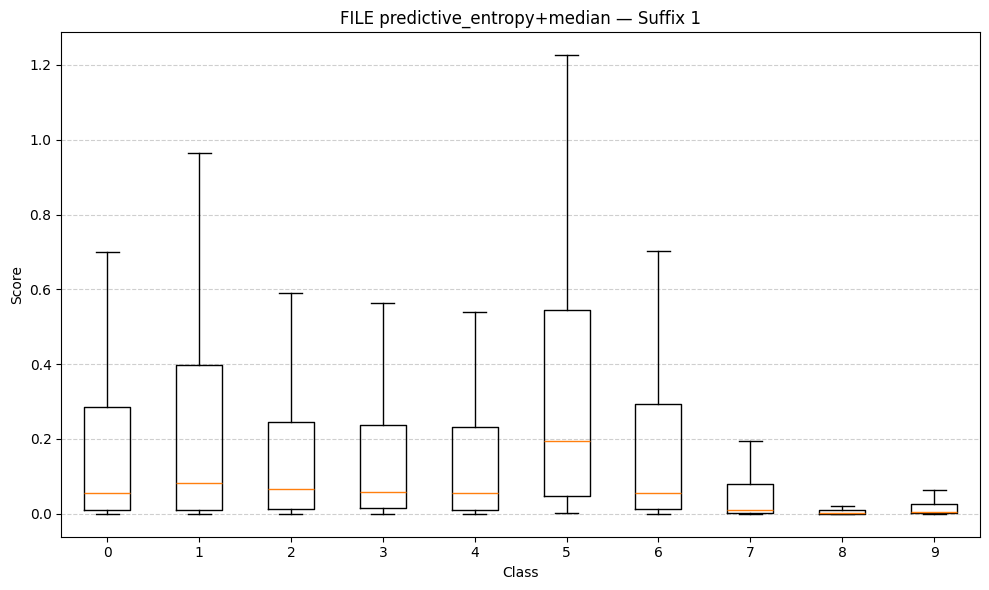

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


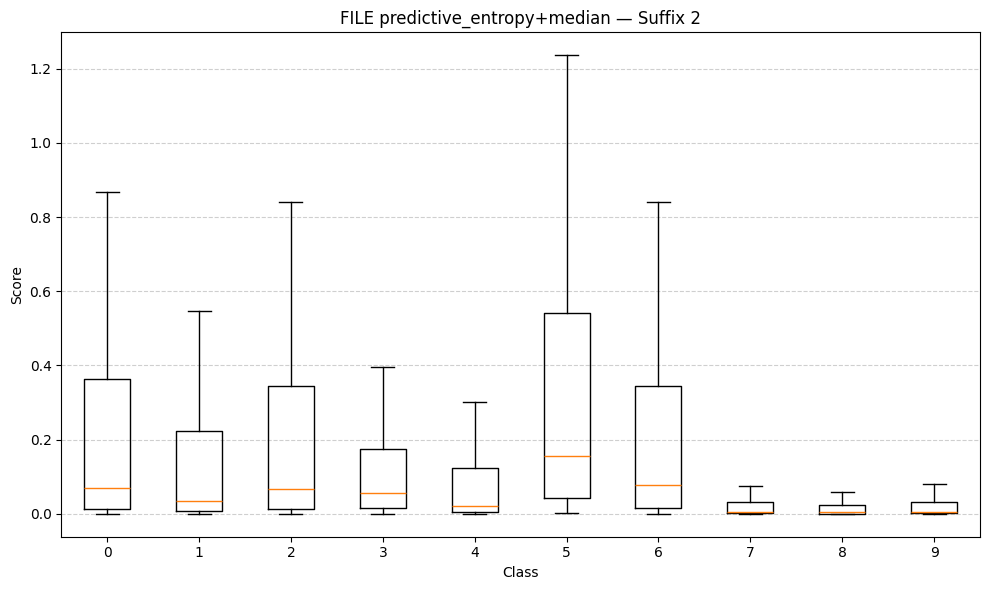

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


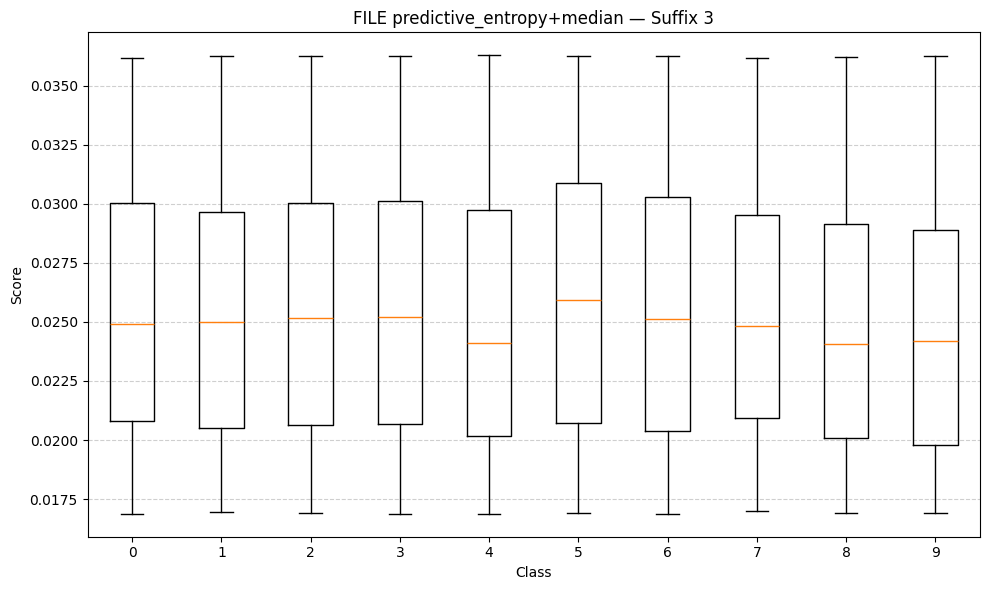

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


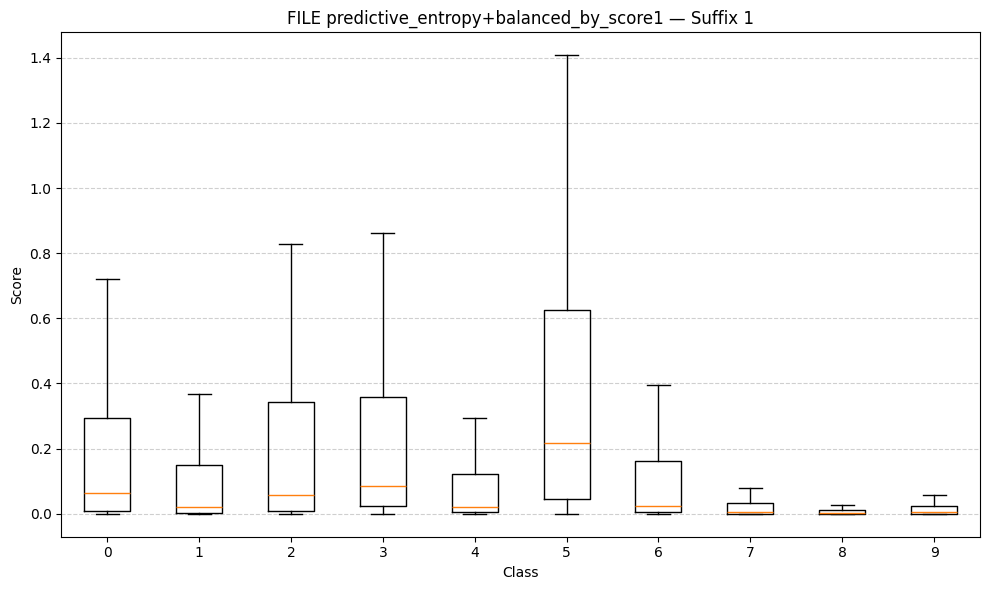

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


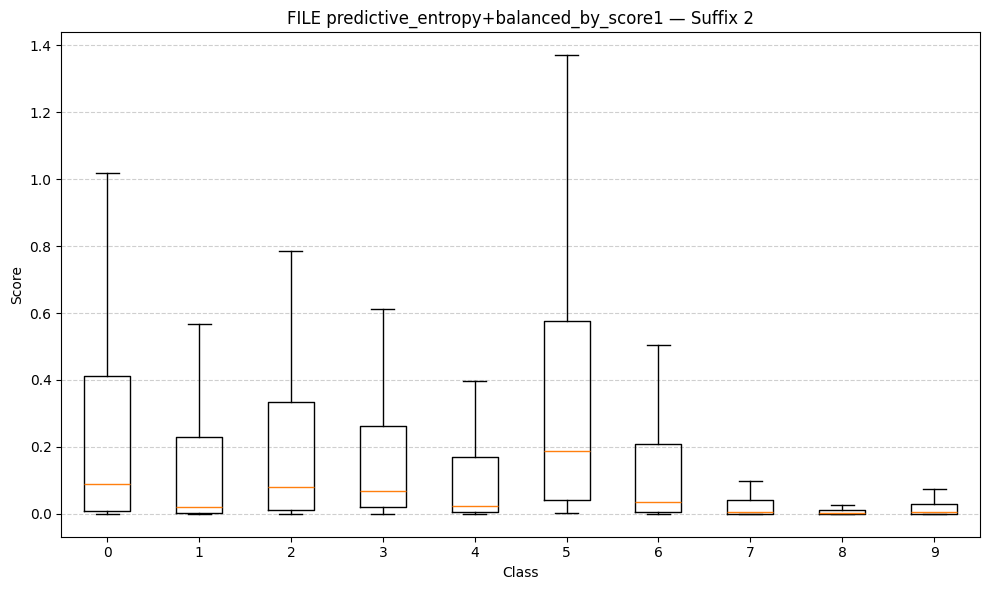

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


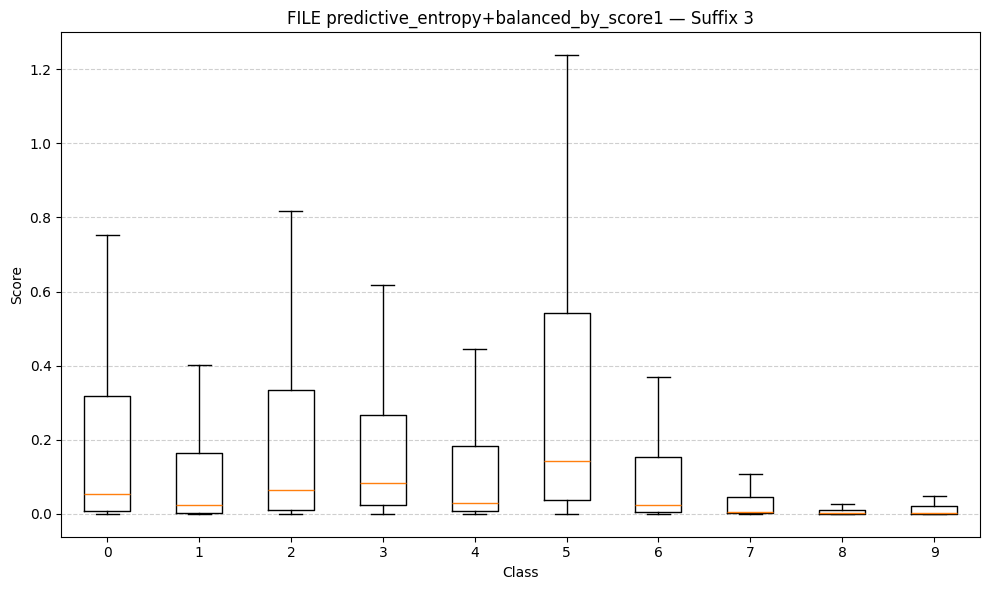

In [8]:
# Per-suffix only:
display_uncertainty_distributions(
    model_name="resnet18",
    dataset_name="CIFAR10",
    keep_fraction=0.9,
    scoring_name="predictive_entropy",
    selection_names=["top","bottom","balanced_by_label","median","balanced_by_score1"],
    plot_average=False
)

Files already downloaded and verified
Files already downloaded and verified
Modified fc layer: updated out_features to 10.
Loaded weights from file: models/resnet18_CIFAR10_1


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


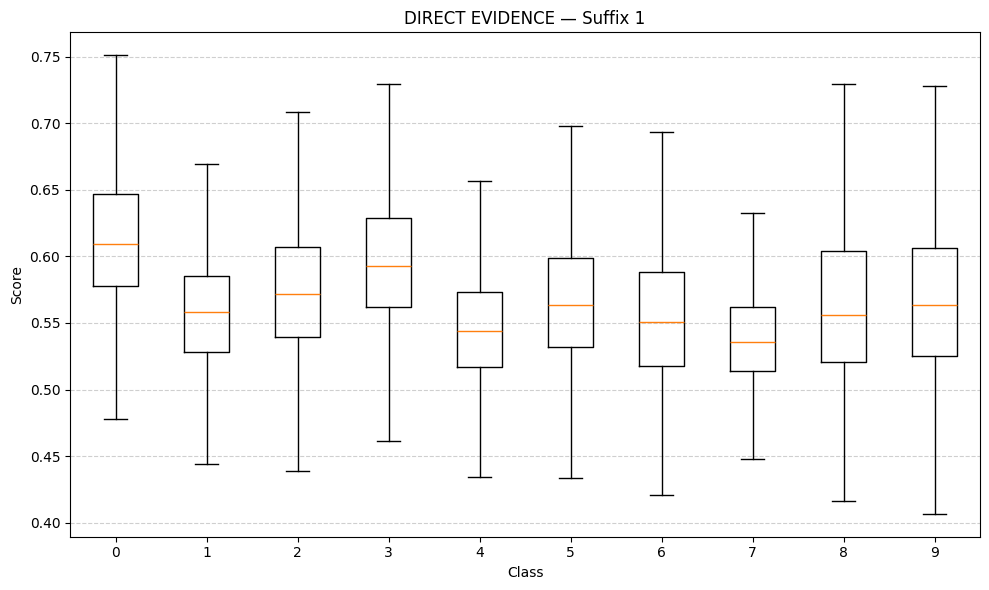

Modified fc layer: updated out_features to 10.
Loaded weights from file: models/resnet18_CIFAR10_2


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


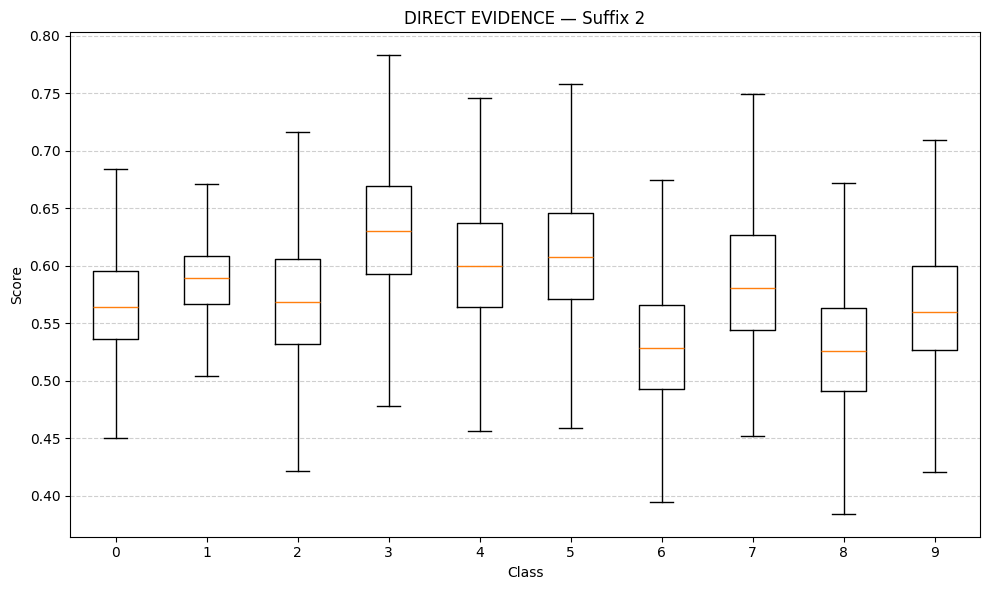

Modified fc layer: updated out_features to 10.
Loaded weights from file: models/resnet18_CIFAR10_3


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


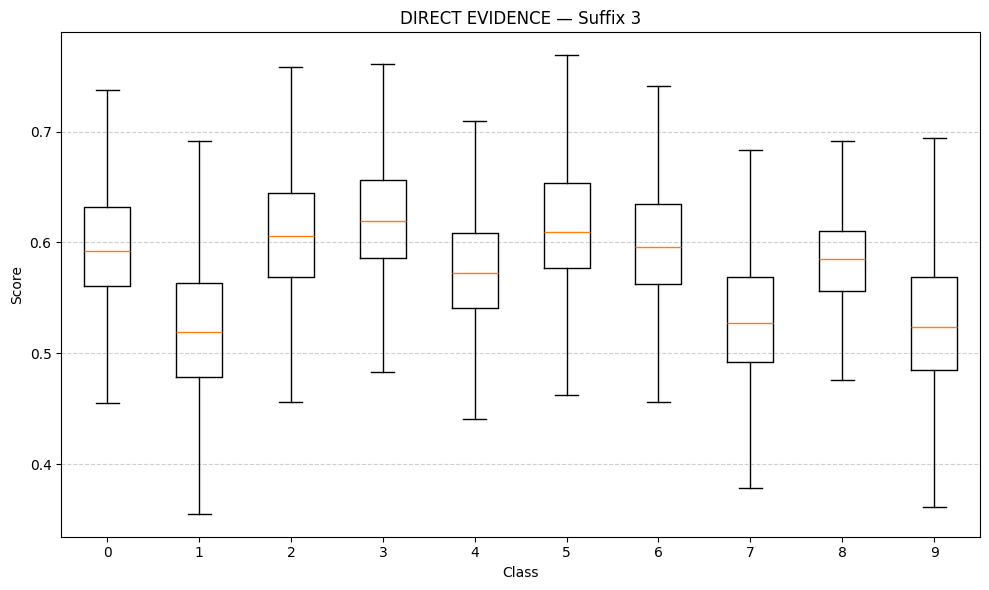

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


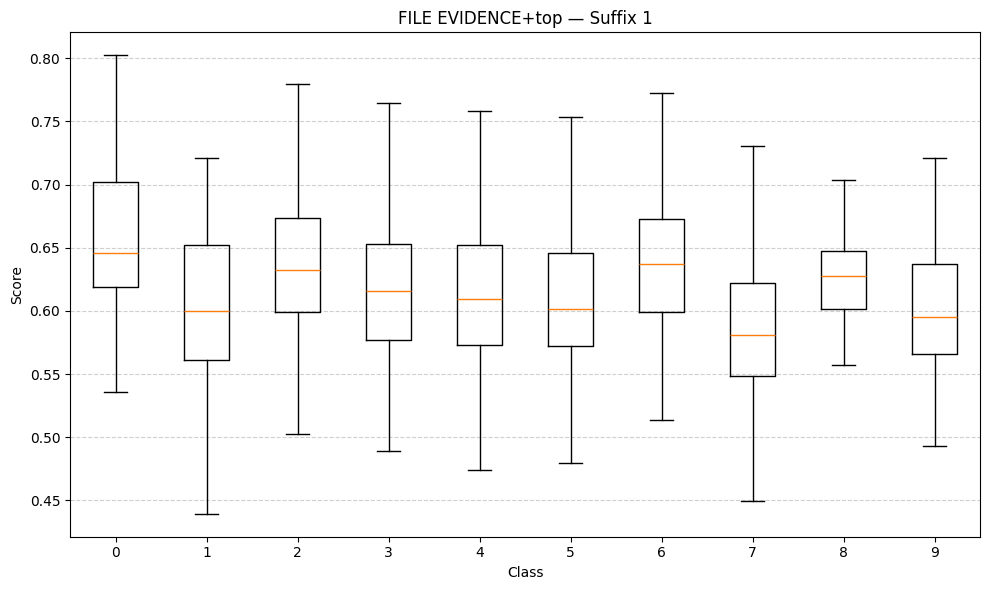

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


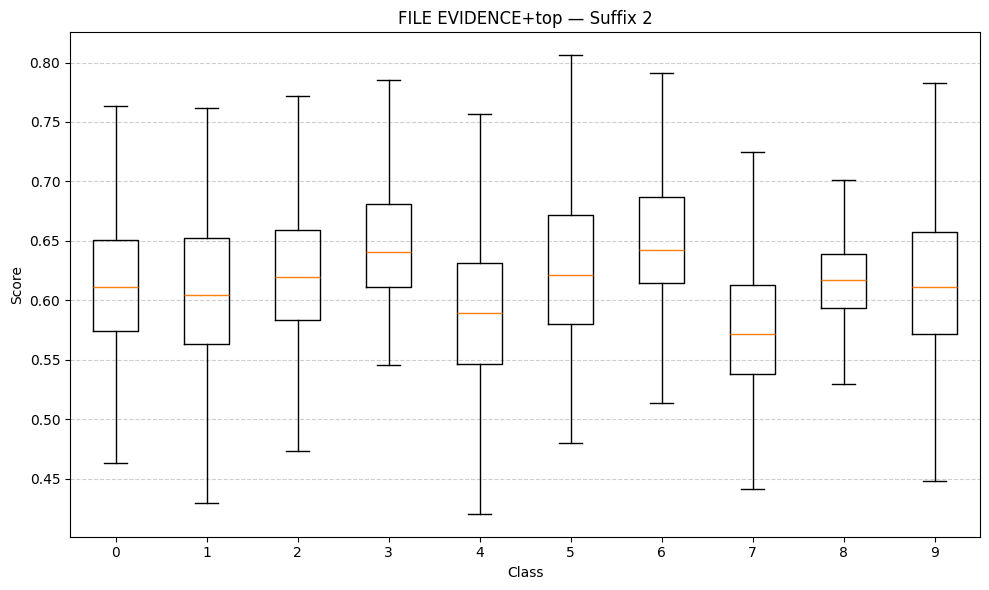

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


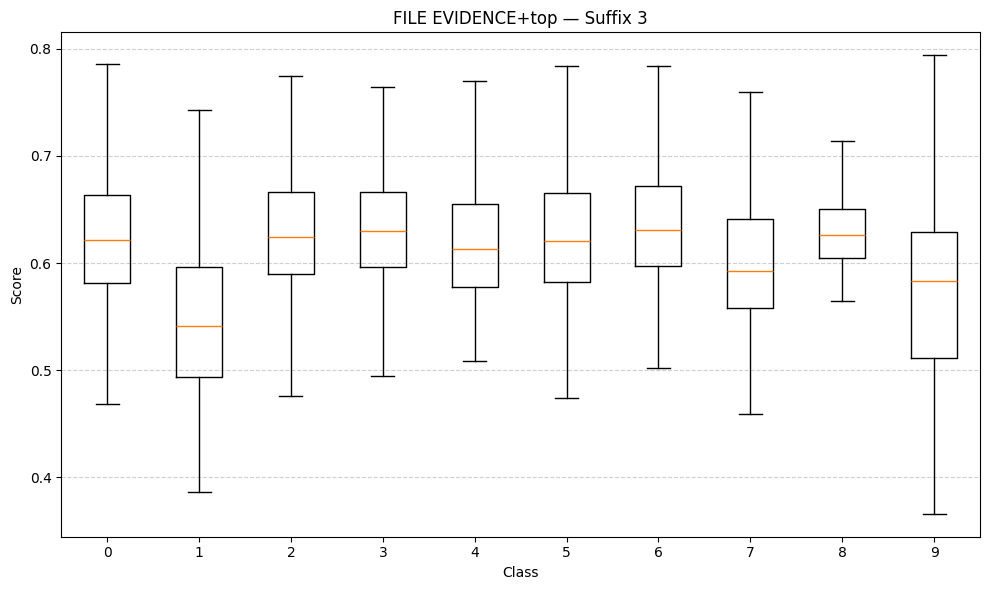

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


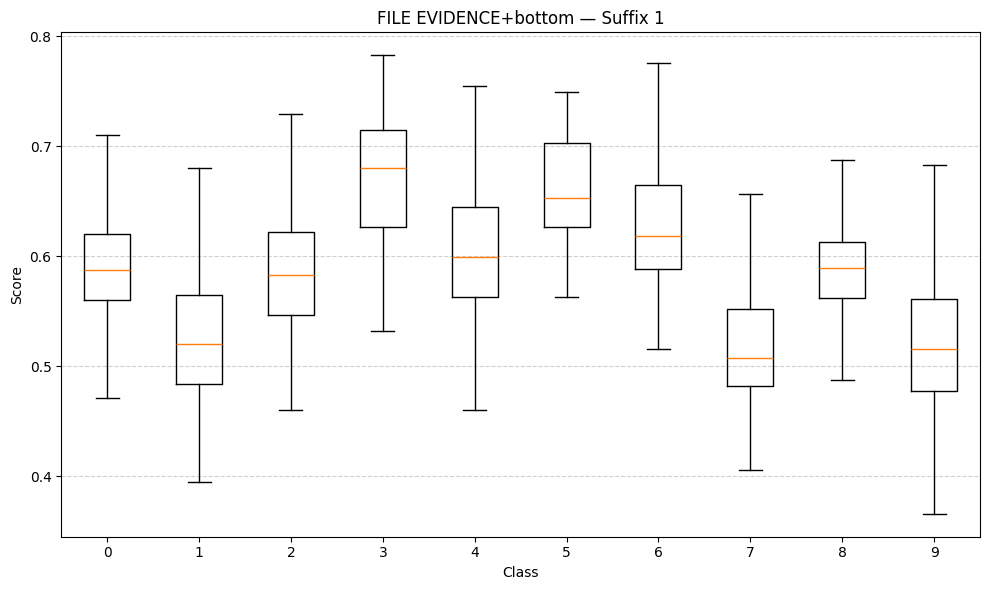

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


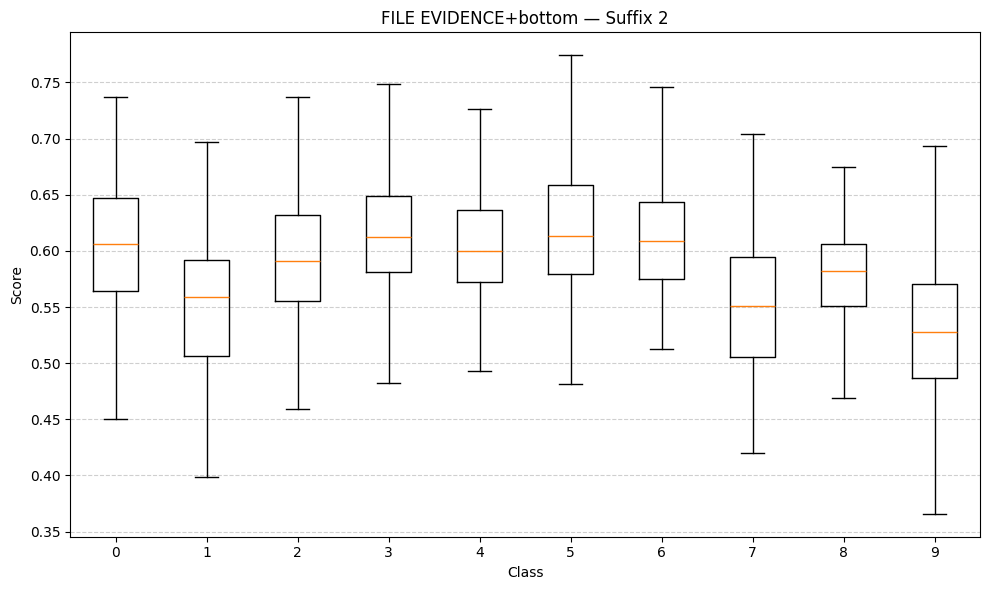

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


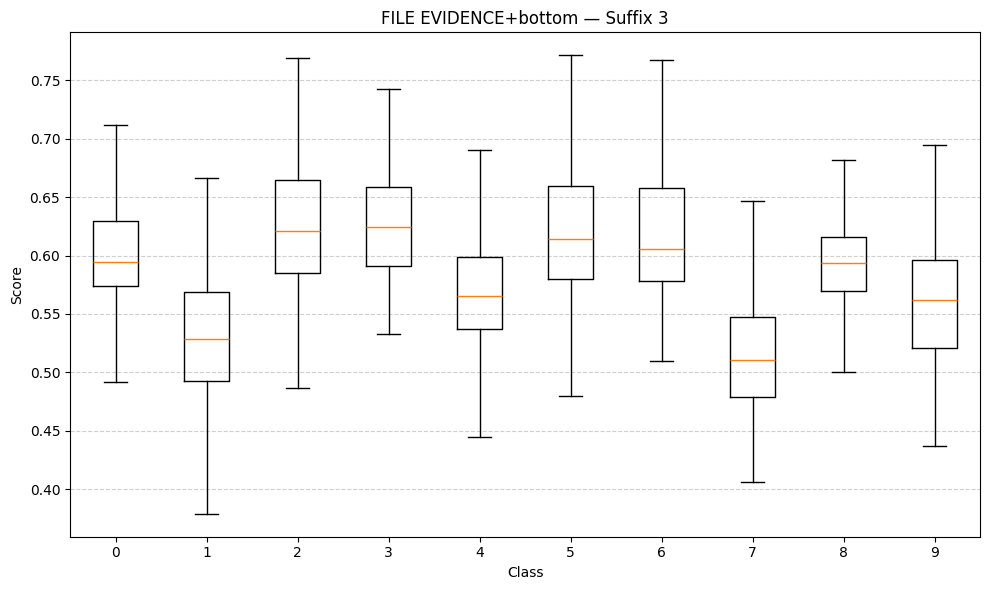

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


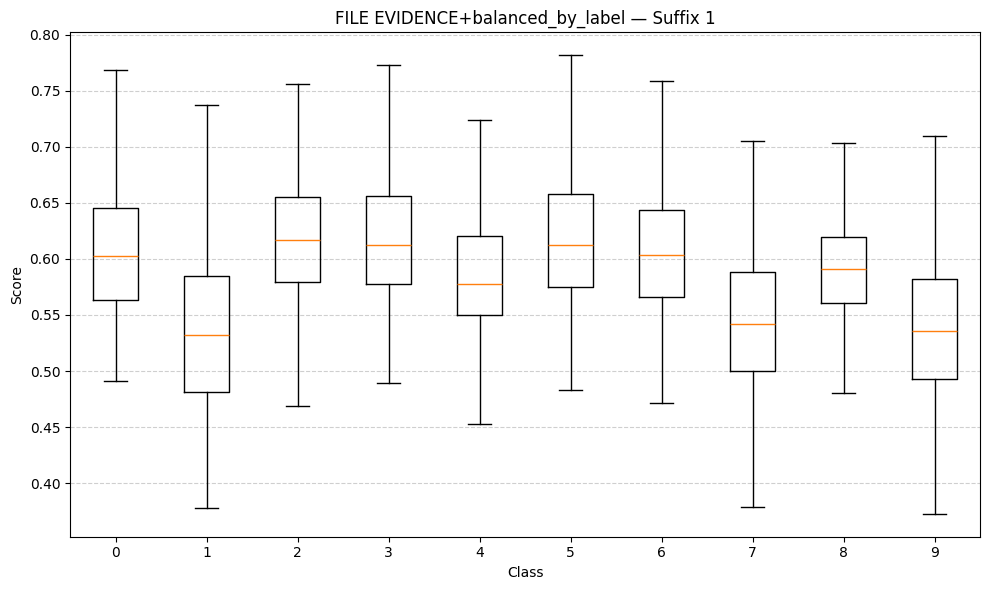

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


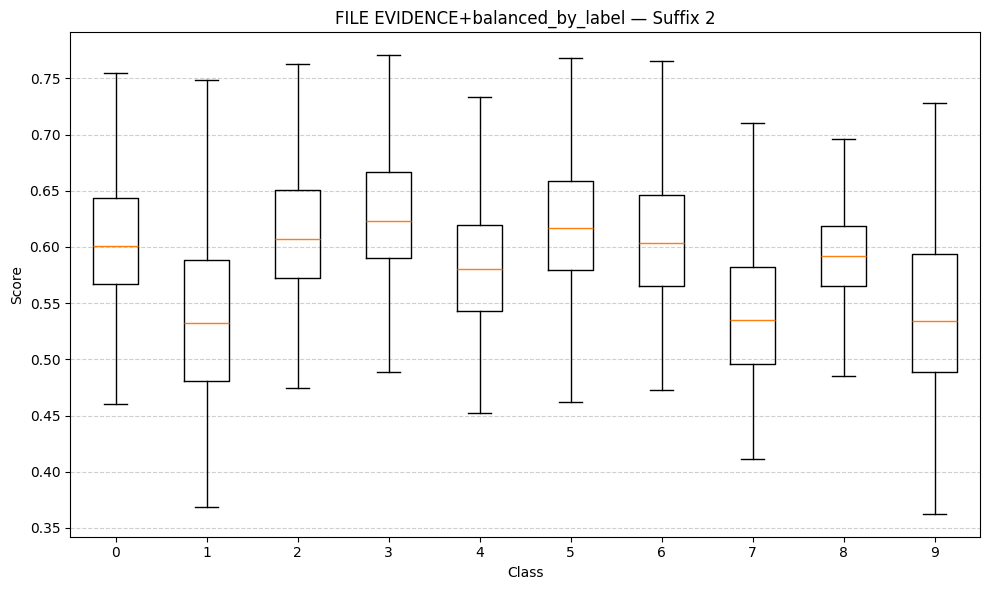

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


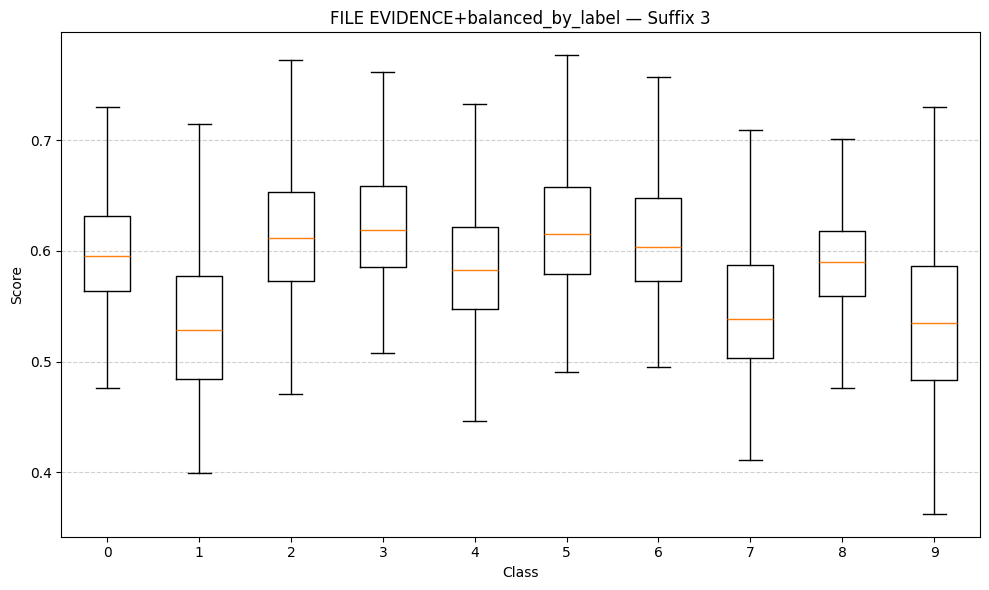

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


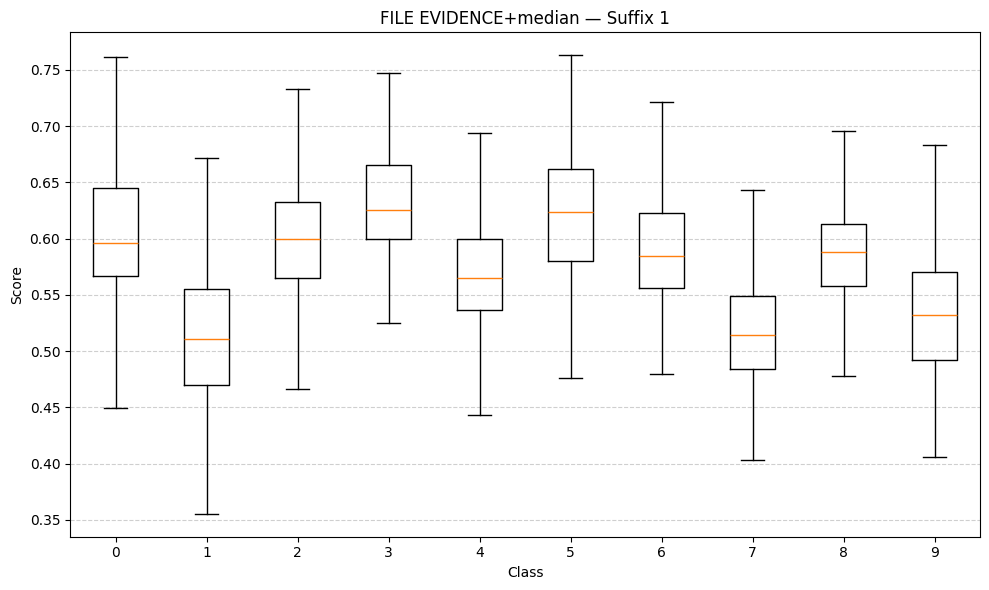

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


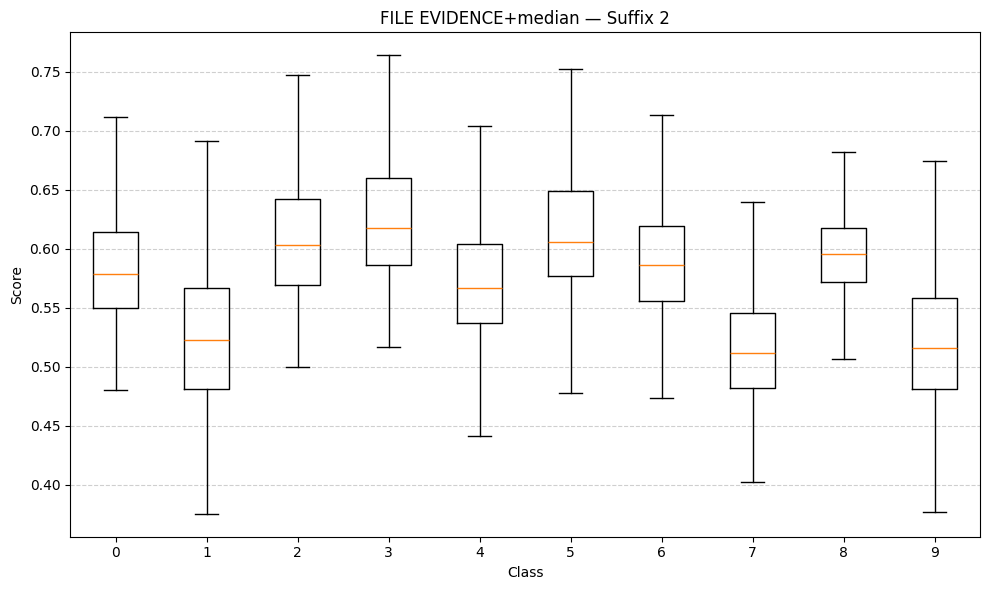

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


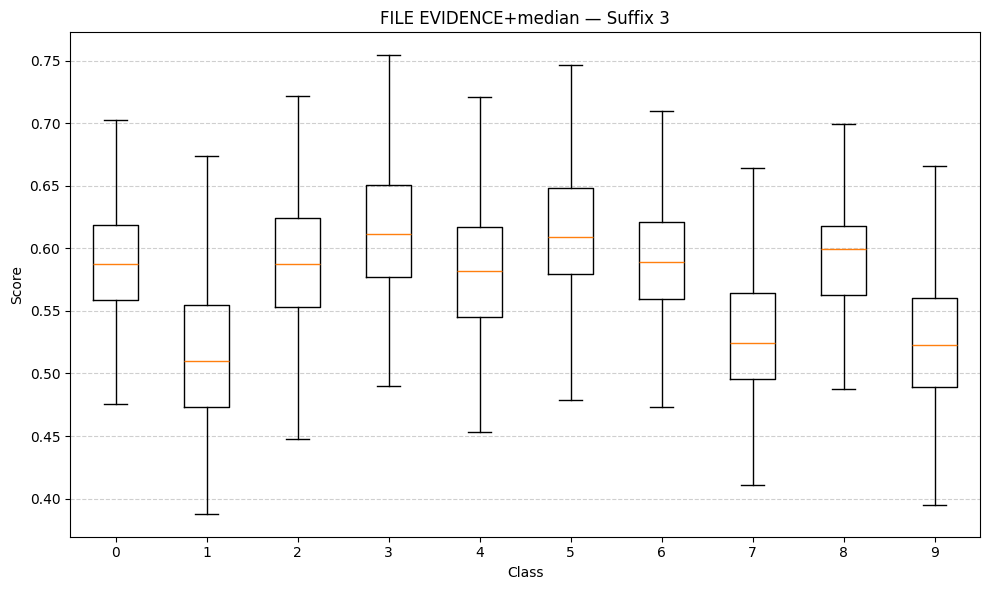

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


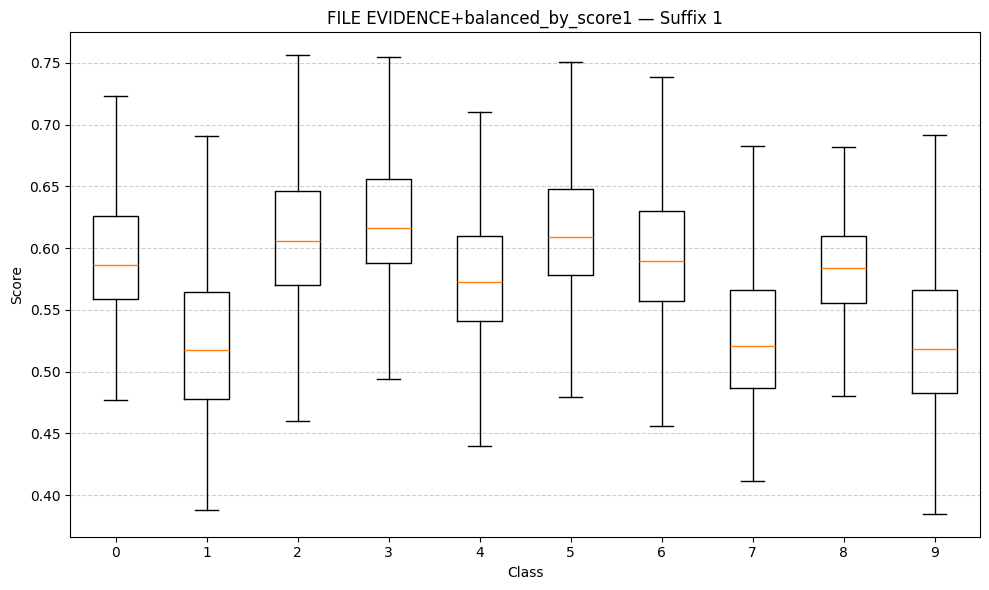

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


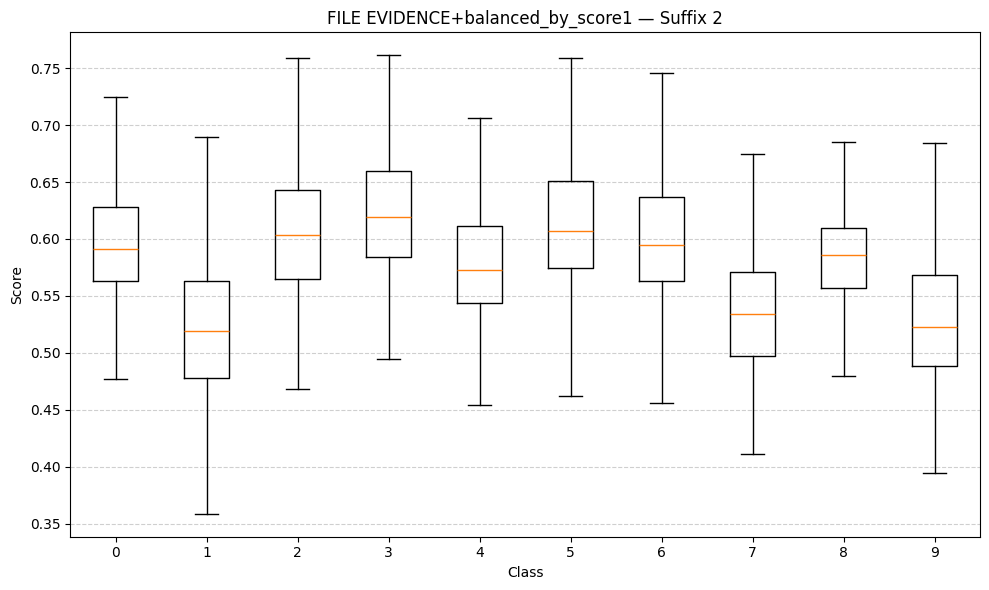

Files already downloaded and verified
Files already downloaded and verified


C:\Users\zeyud\AppData\Local\Temp\ipykernel_4976\1307202481.py:56: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=classes, showfliers=False)


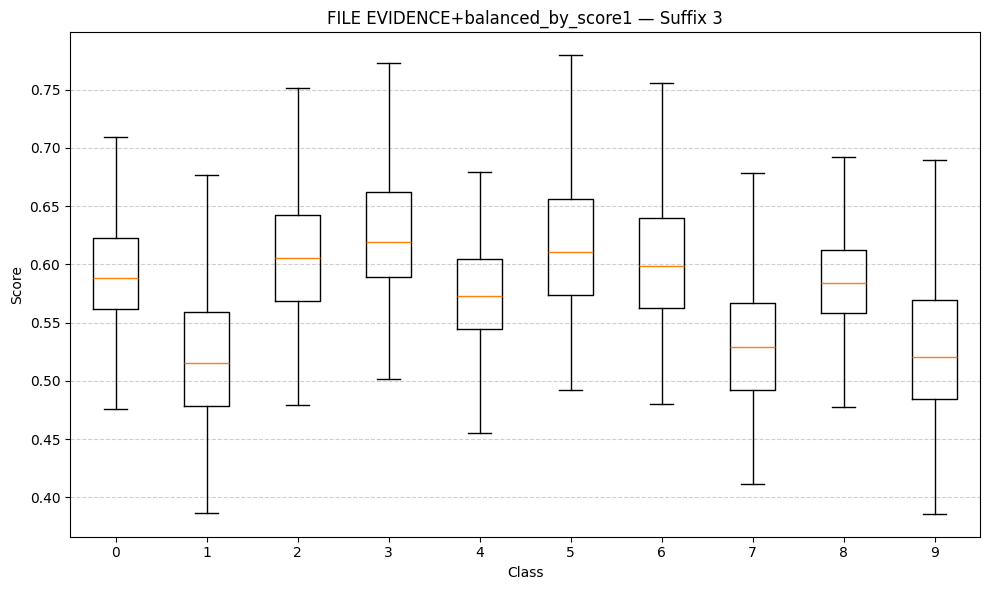

In [9]:
# Per-suffix only:
display_uncertainty_distributions(
    model_name="resnet18",
    dataset_name="CIFAR10",
    keep_fraction=0.9,
    scoring_name="EVIDENCE",
    selection_names=["top","bottom","balanced_by_label","median","balanced_by_score1"],
    plot_average=False
)